# NCAA Basketball Network Project — Baseline Notebook

This notebook sets up the **baseline network analysis** for the final paper.

## Paper direction
We are treating NCAA regular-season play as a **network science** problem rather than a bracket-prediction problem.

### Core idea
- **Nodes** = teams  
- **Undirected weighted edges** = teams played each other, weighted by number of meetings  
- **Directed weighted edges** = loser → winner, weighted by number of wins  

### Main research direction
We want to study how conference structure shapes:
1. **community structure**,
2. **bridge teams / bridge conferences**, and
3. **global comparability / embeddedness** in the national schedule network.

This notebook focuses on the **baseline descriptive graphs and tables** that will likely support the first draft of the paper.

## 0. Notebook roadmap

This notebook does the following:

1. Loads the Kaggle data files we need.
2. Builds a season-level **schedule graph** and **results graph**.
3. Computes cross-season summary statistics.
4. Produces baseline figures for a selected season:
   - conference-colored schedule graph,
   - degree and weighted-degree histograms,
   - conference meta-graph,
   - top centrality tables,
   - weighted degree vs. betweenness scatter.
5. Saves figures and tables into an `outputs/` folder.

Later notebooks / sections can extend this with:
- community detection,
- null model comparisons,
- Laplacian-based comparability scores,
- optional use of detailed box-score data.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms.community.quality import modularity

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

In [2]:
# ----------------------------
# Paths / configuration
# ----------------------------
DATA_DIR = Path(".")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TEAMS_PATH = DATA_DIR / "MTeams.csv"
CONF_PATH = DATA_DIR / "MTeamConferences.csv"
REG_COMPACT_PATH = DATA_DIR / "MRegularSeasonCompactResults.csv"
REG_DETAILED_PATH = DATA_DIR / "MRegularSeasonDetailedResults.csv"  # optional extension

# Main season to visualize in detail
SEASON = 2025

# If True, later extensions can use detailed results.
USE_DETAILED_RESULTS = False

## 1. Load data

In [3]:
teams = pd.read_csv(TEAMS_PATH)
team_confs = pd.read_csv(CONF_PATH)
reg_compact = pd.read_csv(REG_COMPACT_PATH)

# Optional file for later feature extensions (not used in baseline analysis)
reg_detailed = None
if USE_DETAILED_RESULTS and REG_DETAILED_PATH.exists():
    reg_detailed = pd.read_csv(REG_DETAILED_PATH)

print("teams:", teams.shape)
print("team_confs:", team_confs.shape)
print("reg_compact:", reg_compact.shape)
if reg_detailed is not None:
    print("reg_detailed:", reg_detailed.shape)

teams: (381, 4)
team_confs: (13753, 3)
reg_compact: (198079, 8)


In [4]:
display(teams.head())
display(team_confs.head())
display(reg_compact.head())

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


,Season,TeamID,ConfAbbrev
0,1985,1102,wac
1,1985,1103,ovc
2,1985,1104,sec
3,1985,1106,swac
4,1985,1108,swac


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


## 2. Basic validation
We use the intersection of seasons that appear in both:
- regular-season results, and
- conference membership.

In [5]:
valid_seasons = sorted(set(reg_compact["Season"]).intersection(set(team_confs["Season"])))
print(f"Valid seasons with conference labels: {valid_seasons[0]} to {valid_seasons[-1]} ({len(valid_seasons)} seasons)")

if SEASON not in valid_seasons:
    raise ValueError(f"SEASON={SEASON} is not in the valid intersection of seasons.")

Valid seasons with conference labels: 1985 to 2026 (42 seasons)


## 3. Helper functions
These functions build the core graph objects and summary tables.

In [6]:
team_name_map = teams.set_index("TeamID")["TeamName"].to_dict()

def build_season_frames(season, reg_df=reg_compact, conf_df=team_confs):
    games = reg_df.loc[reg_df["Season"] == season].copy()
    confs = conf_df.loc[conf_df["Season"] == season].copy()

    # undirected pair for schedule graph
    games["TeamA"] = games[["WTeamID", "LTeamID"]].min(axis=1)
    games["TeamB"] = games[["WTeamID", "LTeamID"]].max(axis=1)

    return games, confs

def build_graphs_for_season(season, reg_df=reg_compact, conf_df=team_confs):
    games, confs = build_season_frames(season, reg_df=reg_df, conf_df=conf_df)
    conf_map = confs.set_index("TeamID")["ConfAbbrev"].to_dict()

    # --- Undirected schedule graph ---
    edge_weights = (
        games.groupby(["TeamA", "TeamB"])
        .size()
        .reset_index(name="weight")
    )
    G = nx.Graph()
    for row in edge_weights.itertuples(index=False):
        G.add_edge(int(row.TeamA), int(row.TeamB), weight=int(row.weight))

    # --- Directed results graph: loser -> winner ---
    result_weights = (
        games.groupby(["LTeamID", "WTeamID"])
        .size()
        .reset_index(name="weight")
    )
    DG = nx.DiGraph()
    for row in result_weights.itertuples(index=False):
        DG.add_edge(int(row.LTeamID), int(row.WTeamID), weight=int(row.weight))

    # Attach metadata
    node_ids = set(G.nodes()) | set(DG.nodes())
    attrs = {
        int(team_id): {
            "TeamName": team_name_map.get(int(team_id), str(team_id)),
            "Conference": conf_map.get(int(team_id), "unknown")
        }
        for team_id in node_ids
    }
    nx.set_node_attributes(G, attrs)
    nx.set_node_attributes(DG, attrs)

    return G, DG, games, confs

def build_conference_meta_graph(G):
    """Conference-level graph based on interconference games.
    Node = conference
    Edge weight = total number of regular-season games between two conferences
    """
    conf_edge_weights = {}
    conf_sizes = {}

    for node, data in G.nodes(data=True):
        conf = data.get("Conference", "unknown")
        conf_sizes[conf] = conf_sizes.get(conf, 0) + 1

    for u, v, data in G.edges(data=True):
        cu = G.nodes[u].get("Conference", "unknown")
        cv = G.nodes[v].get("Conference", "unknown")
        if cu == cv:
            continue
        a, b = sorted([cu, cv])
        conf_edge_weights[(a, b)] = conf_edge_weights.get((a, b), 0) + data.get("weight", 1)

    CG = nx.Graph()
    for conf, size in conf_sizes.items():
        CG.add_node(conf, size=size)
    for (a, b), w in conf_edge_weights.items():
        CG.add_edge(a, b, weight=w)
    return CG

def season_summary_row(season):
    G, DG, games, confs = build_graphs_for_season(season)

    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)
    n_components = nx.number_connected_components(G)
    components = list(nx.connected_components(G))
    gcc_nodes = max(components, key=len)
    G_gcc = G.subgraph(gcc_nodes).copy()

    communities = {}
    for node, data in G.nodes(data=True):
        communities.setdefault(data.get("Conference", "unknown"), []).append(node)
    conference_partition = list(communities.values())

    within_weight = 0
    between_weight = 0
    for u, v, data in G.edges(data=True):
        w = data.get("weight", 1)
        if G.nodes[u].get("Conference") == G.nodes[v].get("Conference"):
            within_weight += w
        else:
            between_weight += w

    total_weight = within_weight + between_weight

    return {
        "Season": season,
        "Teams": n,
        "Games": len(games),
        "Edges": m,
        "Density": density,
        "Components": n_components,
        "GiantComponentShare": len(gcc_nodes) / n if n else np.nan,
        "AvgPathLength_GCC": nx.average_shortest_path_length(G_gcc) if len(G_gcc) > 1 else np.nan,
        "AvgClustering": nx.average_clustering(G),
        "ConferenceModularity": modularity(G, conference_partition, weight="weight"),
        "WithinConfGameFrac": within_weight / total_weight if total_weight else np.nan,
        "BetweenConfGameFrac": between_weight / total_weight if total_weight else np.nan,
        "MeanDegree": np.mean([d for _, d in G.degree()]),
        "MeanWeightedDegree": np.mean([d for _, d in G.degree(weight="weight")]),
        "DirectedEdges": DG.number_of_edges(),
    }

def centrality_table(G, DG, top_n=15):
    weighted_degree = dict(G.degree(weight="weight"))
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)
    closeness = nx.closeness_centrality(G)
    pagerank = nx.pagerank(DG, weight="weight")

    rows = []
    for node in G.nodes():
        rows.append({
            "TeamID": node,
            "TeamName": G.nodes[node].get("TeamName"),
            "Conference": G.nodes[node].get("Conference"),
            "Degree": degree.get(node, np.nan),
            "WeightedDegree": weighted_degree.get(node, np.nan),
            "Betweenness": betweenness.get(node, np.nan),
            "Closeness": closeness.get(node, np.nan),
            "PageRank": pagerank.get(node, np.nan),
        })
    df = pd.DataFrame(rows)
    return df.sort_values(["WeightedDegree", "Betweenness"], ascending=False).reset_index(drop=True)

def within_between_conference_table(G):
    rows = []
    for u, v, data in G.edges(data=True):
        conf_u = G.nodes[u].get("Conference", "unknown")
        conf_v = G.nodes[v].get("Conference", "unknown")
        rows.append({
            "TeamU": u,
            "TeamV": v,
            "ConfU": conf_u,
            "ConfV": conf_v,
            "weight": data.get("weight", 1),
            "EdgeType": "Within" if conf_u == conf_v else "Between"
        })
    edge_df = pd.DataFrame(rows)
    summary = (
        edge_df.groupby("EdgeType")["weight"]
        .agg(["sum", "mean", "count"])
        .rename(columns={"sum": "TotalGames", "mean": "AvgWeight", "count": "NumEdges"})
        .reset_index()
    )
    total_games = summary["TotalGames"].sum()
    summary["GameShare"] = summary["TotalGames"] / total_games if total_games else np.nan
    return edge_df, summary

def conference_connectivity_table(CG):
    rows = []
    for conf in CG.nodes():
        rows.append({
            "Conference": conf,
            "TeamsInSeason": CG.nodes[conf].get("size", np.nan),
            "InterconfDegree": CG.degree(conf),
            "InterconfWeightedDegree": CG.degree(conf, weight="weight"),
        })
    df = pd.DataFrame(rows)
    return df.sort_values("InterconfWeightedDegree", ascending=False).reset_index(drop=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

def finish_figure(title=None, filename=None):
    if title:
        plt.title(title)
    plt.tight_layout()
    if filename:
        path = OUTPUT_DIR / filename
        plt.savefig(path, bbox_inches="tight")
        print(f"Saved: {path}")
    plt.show()

## 4. Cross-season summary table
This gives paper-level context before we zoom into one season.

In [7]:
season_summary = pd.DataFrame([season_summary_row(season) for season in valid_seasons])
display(season_summary.head())
display(season_summary.tail())

save_table(season_summary, "season_summary")

,Season,Teams,Games,Edges,Density,Components,GiantComponentShare,AvgPathLength_GCC,AvgClustering,ConferenceModularity,WithinConfGameFrac,BetweenConfGameFrac,MeanDegree,MeanWeightedDegree,DirectedEdges
0,1985,282,3737,2407,0.060751,1,1.0,2.453345,0.278337,0.562981,0.597003,0.402997,17.070922,26.503546,2915
1,1986,283,3783,2431,0.060923,1,1.0,2.462522,0.284063,0.558324,0.590537,0.409463,17.180212,26.734982,2940
2,1987,290,3915,2544,0.060709,1,1.0,2.434459,0.267691,0.555434,0.586973,0.413027,17.544828,27.000000,3055
3,1988,290,3955,2585,0.061687,1,1.0,2.417039,0.268145,0.562373,0.594185,0.405815,17.827586,27.275862,3106
4,1989,293,4037,2659,0.062158,1,1.0,2.400603,0.254166,0.547867,0.580381,0.419619,18.150171,27.556314,3168


,Season,Teams,Games,Edges,Density,Components,GiantComponentShare,AvgPathLength_GCC,AvgClustering,ConferenceModularity,WithinConfGameFrac,BetweenConfGameFrac,MeanDegree,MeanWeightedDegree,DirectedEdges
37,2022,358,5345,3677,0.057540,1,1.0,2.427570,0.304124,0.622039,0.654443,0.345557,20.541899,29.860335,4269
38,2023,363,5602,3888,0.059175,1,1.0,2.384396,0.293057,0.609626,0.641735,0.358265,21.421488,30.865014,4527
39,2024,362,5607,3940,0.060299,1,1.0,2.378736,0.292734,0.602905,0.635456,0.364544,21.767956,30.977901,4582
40,2025,364,5641,4043,0.061196,1,1.0,2.374868,0.310107,0.611861,0.646339,0.353661,22.214286,30.994505,4624
41,2026,365,5149,3988,0.060033,1,1.0,2.382734,0.299980,0.579868,0.614100,0.385900,21.852055,28.213699,4481


Saved: outputs/season_summary.csv


## 5. Cross-season baseline figures
These are useful for the introduction / methods section of the short paper because they show the NCAA schedule network at a macro level over time.

Saved: outputs/teams_by_season.png


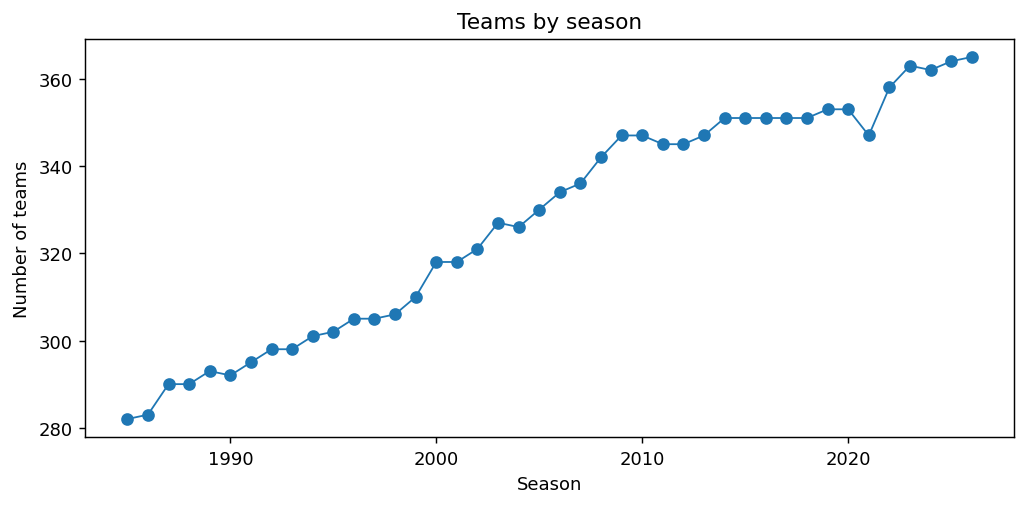

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["Teams"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Number of teams")
finish_figure("Teams by season", "teams_by_season.png")

Saved: outputs/edges_by_season.png


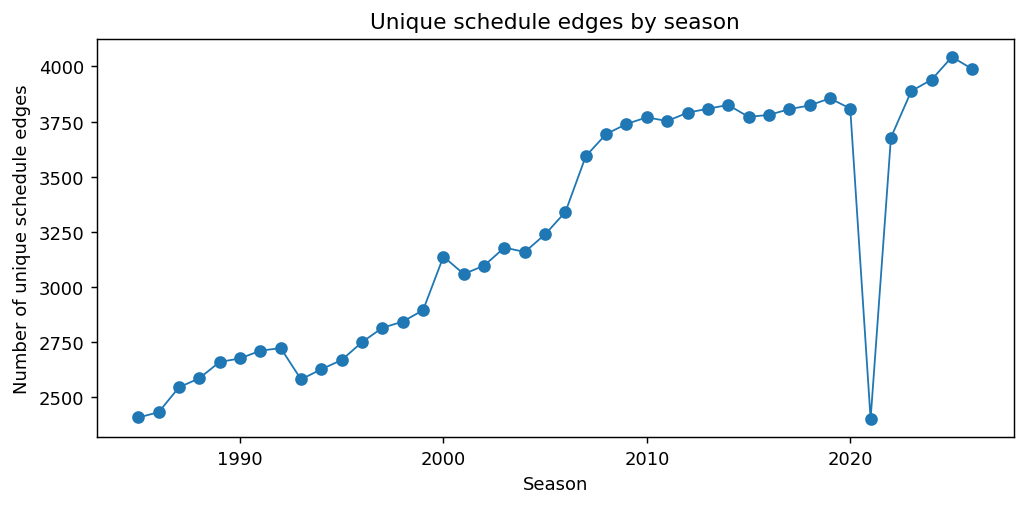

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["Edges"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Number of unique schedule edges")
finish_figure("Unique schedule edges by season", "edges_by_season.png")

Saved: outputs/conference_modularity_by_season.png


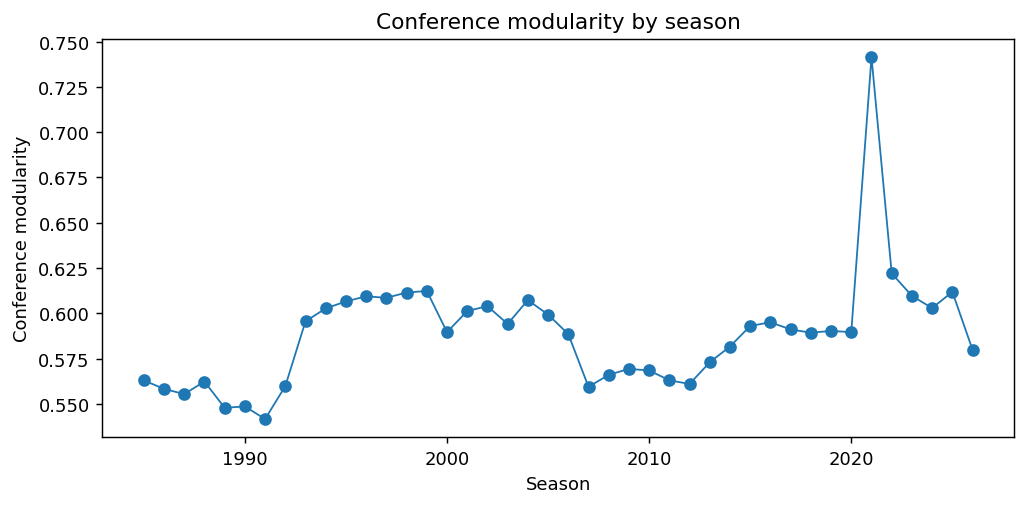

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["ConferenceModularity"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Conference modularity")
finish_figure("Conference modularity by season", "conference_modularity_by_season.png")

Saved: outputs/between_conf_fraction_by_season.png


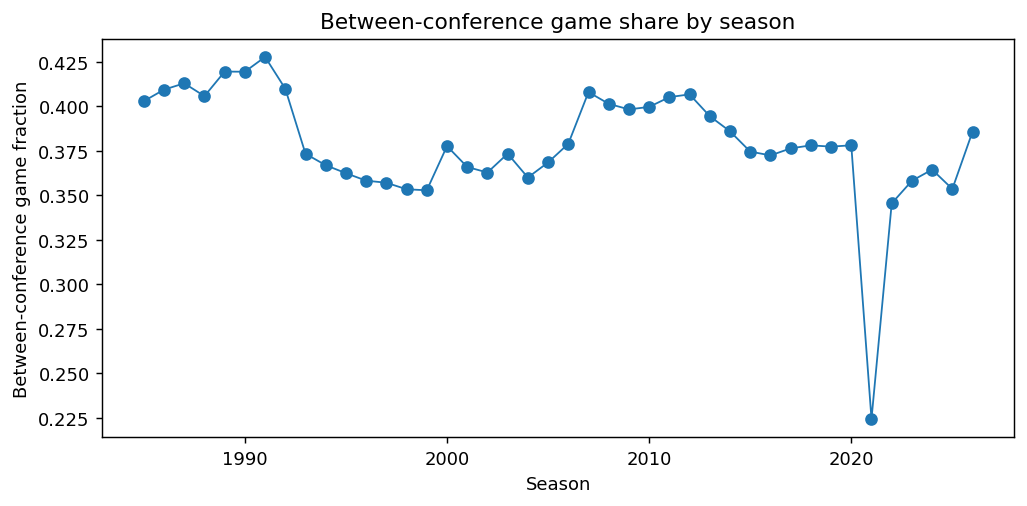

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(season_summary["Season"], season_summary["BetweenConfGameFrac"], marker="o", linewidth=1)
plt.xlabel("Season")
plt.ylabel("Between-conference game fraction")
finish_figure("Between-conference game share by season", "between_conf_fraction_by_season.png")

## 6. Build graphs for the selected season
This season will drive the main figures and tables in the baseline analysis.

In [12]:
G, DG, games_season, confs_season = build_graphs_for_season(SEASON)
CG = build_conference_meta_graph(G)

print(f"Selected season: {SEASON}")
print(f"Schedule graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Results graph:  {DG.number_of_nodes()} nodes, {DG.number_of_edges()} directed edges")
print(f"Conference meta-graph: {CG.number_of_nodes()} conference nodes, {CG.number_of_edges()} edges")

Selected season: 2025
Schedule graph: 364 nodes, 4043 edges
Results graph:  364 nodes, 4624 directed edges
Conference meta-graph: 31 conference nodes, 383 edges


In [13]:
season_row = season_summary.loc[season_summary["Season"] == SEASON].copy()
display(season_row)

,Season,Teams,Games,Edges,Density,Components,GiantComponentShare,AvgPathLength_GCC,AvgClustering,ConferenceModularity,WithinConfGameFrac,BetweenConfGameFrac,MeanDegree,MeanWeightedDegree,DirectedEdges
40,2025,364,5641,4043,0.061196,1,1.0,2.374868,0.310107,0.611861,0.646339,0.353661,22.214286,30.994505,4624


## 7. One-season descriptive tables

In [14]:
edge_df, edge_summary = within_between_conference_table(G)
centrality_df = centrality_table(G, DG, top_n=15)
conf_connectivity_df = conference_connectivity_table(CG)

display(edge_summary)
display(centrality_df.head(15))
display(conf_connectivity_df.head(15))

save_table(edge_summary, f"edge_type_summary_{SEASON}")
save_table(centrality_df, f"centrality_table_{SEASON}")
save_table(conf_connectivity_df, f"conference_connectivity_{SEASON}")

,EdgeType,TotalGames,AvgWeight,NumEdges,GameShare
0,Between,1995,1.005544,1984,0.353661
1,Within,3646,1.770763,2059,0.646339


,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
0,1458,Wisconsin,big_ten,28,35,0.005546,0.455458,0.007719
1,1314,North Carolina,acc,29,35,0.004969,0.446494,0.003566
2,1181,Duke,acc,28,34,0.006057,0.446494,0.009875
3,1397,Tennessee,sec,28,34,0.005658,0.444853,0.018163
4,1400,Texas,sec,28,34,0.005448,0.444853,0.007226
5,1160,Colorado,big_twelve,25,34,0.005282,0.435252,0.003224
6,1272,Memphis,aac,25,34,0.005177,0.443223,0.008874
7,1238,Jackson St,swac,24,34,0.005011,0.438406,0.000933
8,1222,Houston,big_twelve,26,34,0.004903,0.444308,0.008667
9,1112,Arizona,big_twelve,25,34,0.004708,0.449814,0.006440


,Conference,TeamsInSeason,InterconfDegree,InterconfWeightedDegree
0,sec,16,28,208
1,acc,18,30,199
2,big_ten,18,30,197
3,a_ten,15,27,176
4,big_twelve,16,28,171
5,caa,14,26,162
6,sun_belt,14,25,156
7,aac,13,27,150
8,a_sun,12,26,133
9,swac,12,23,133


Saved: outputs/edge_type_summary_2025.csv
Saved: outputs/centrality_table_2025.csv
Saved: outputs/conference_connectivity_2025.csv


## 8. Conference-colored schedule graph

This is one of the most important visual baselines for the paper.  
The graph should visually suggest:
- strong conference communities,
- sparse cross-conference bridges,
- potential bridge teams between communities.

Because there are many conferences, the legend is intentionally omitted in the first pass.  
Instead, we color each team by conference code.

Saved: outputs/schedule_graph_conference_2025.png


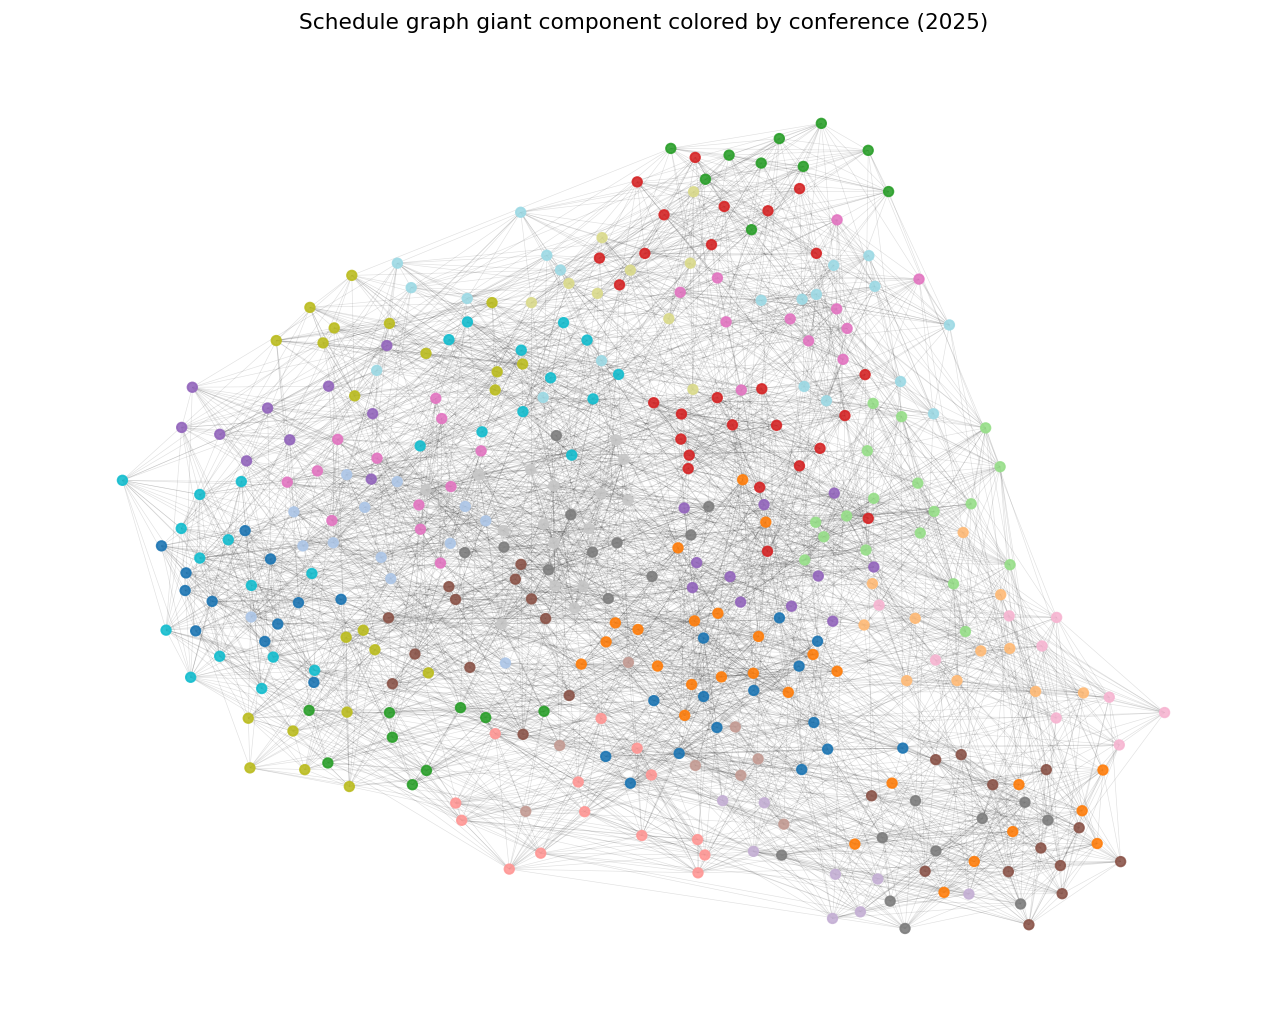

In [15]:
# Map conferences to integer colors
conf_codes = sorted({G.nodes[n].get("Conference", "unknown") for n in G.nodes()})
conf_to_int = {conf: i for i, conf in enumerate(conf_codes)}
node_colors = [conf_to_int[G.nodes[n].get("Conference", "unknown")] for n in G.nodes()]

# Use the giant component for a cleaner plot
gcc_nodes = max(nx.connected_components(G), key=len)
G_gcc = G.subgraph(gcc_nodes).copy()

conf_codes_gcc = sorted({G_gcc.nodes[n].get("Conference", "unknown") for n in G_gcc.nodes()})
conf_to_int_gcc = {conf: i for i, conf in enumerate(conf_codes_gcc)}
node_colors_gcc = [conf_to_int_gcc[G_gcc.nodes[n].get("Conference", "unknown")] for n in G_gcc.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_gcc, seed=42, k=0.22, iterations=80, weight="weight")
nx.draw_networkx_nodes(
    G_gcc,
    pos,
    node_size=28,
    node_color=node_colors_gcc,
    cmap=plt.cm.tab20,
    alpha=0.9,
)
nx.draw_networkx_edges(
    G_gcc,
    pos,
    width=0.35,
    alpha=0.12,
)
plt.axis("off")
finish_figure(f"Schedule graph giant component colored by conference ({SEASON})",
              f"schedule_graph_conference_{SEASON}.png")

## 9. Degree distribution baselines
These histograms help describe network heterogeneity.

Saved: outputs/degree_hist_2025.png


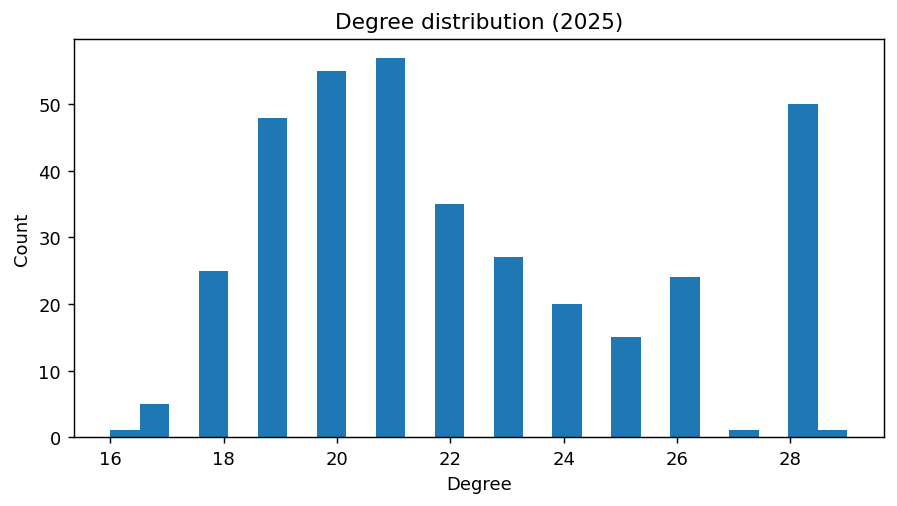

In [16]:
degree_values = [d for _, d in G.degree()]
plt.figure(figsize=(7, 4))
plt.hist(degree_values, bins=25)
plt.xlabel("Degree")
plt.ylabel("Count")
finish_figure(f"Degree distribution ({SEASON})", f"degree_hist_{SEASON}.png")

Saved: outputs/weighted_degree_hist_2025.png


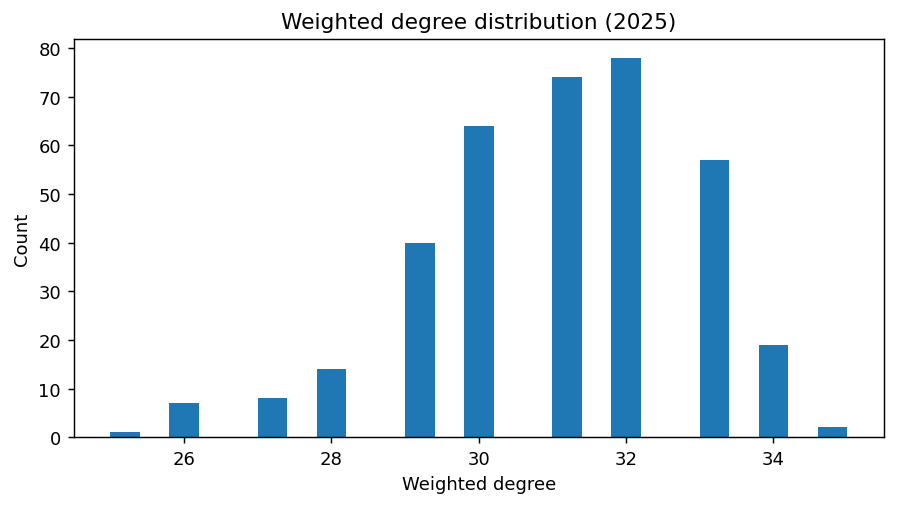

In [17]:
weighted_degree_values = [d for _, d in G.degree(weight="weight")]
plt.figure(figsize=(7, 4))
plt.hist(weighted_degree_values, bins=25)
plt.xlabel("Weighted degree")
plt.ylabel("Count")
finish_figure(f"Weighted degree distribution ({SEASON})", f"weighted_degree_hist_{SEASON}.png")

## 10. Conference meta-graph
This figure compresses the team network into a conference-level network.

Interpretation:
- node size = number of teams in the conference for that season
- edge weight = number of interconference games

Saved: outputs/conference_meta_graph_2025.png


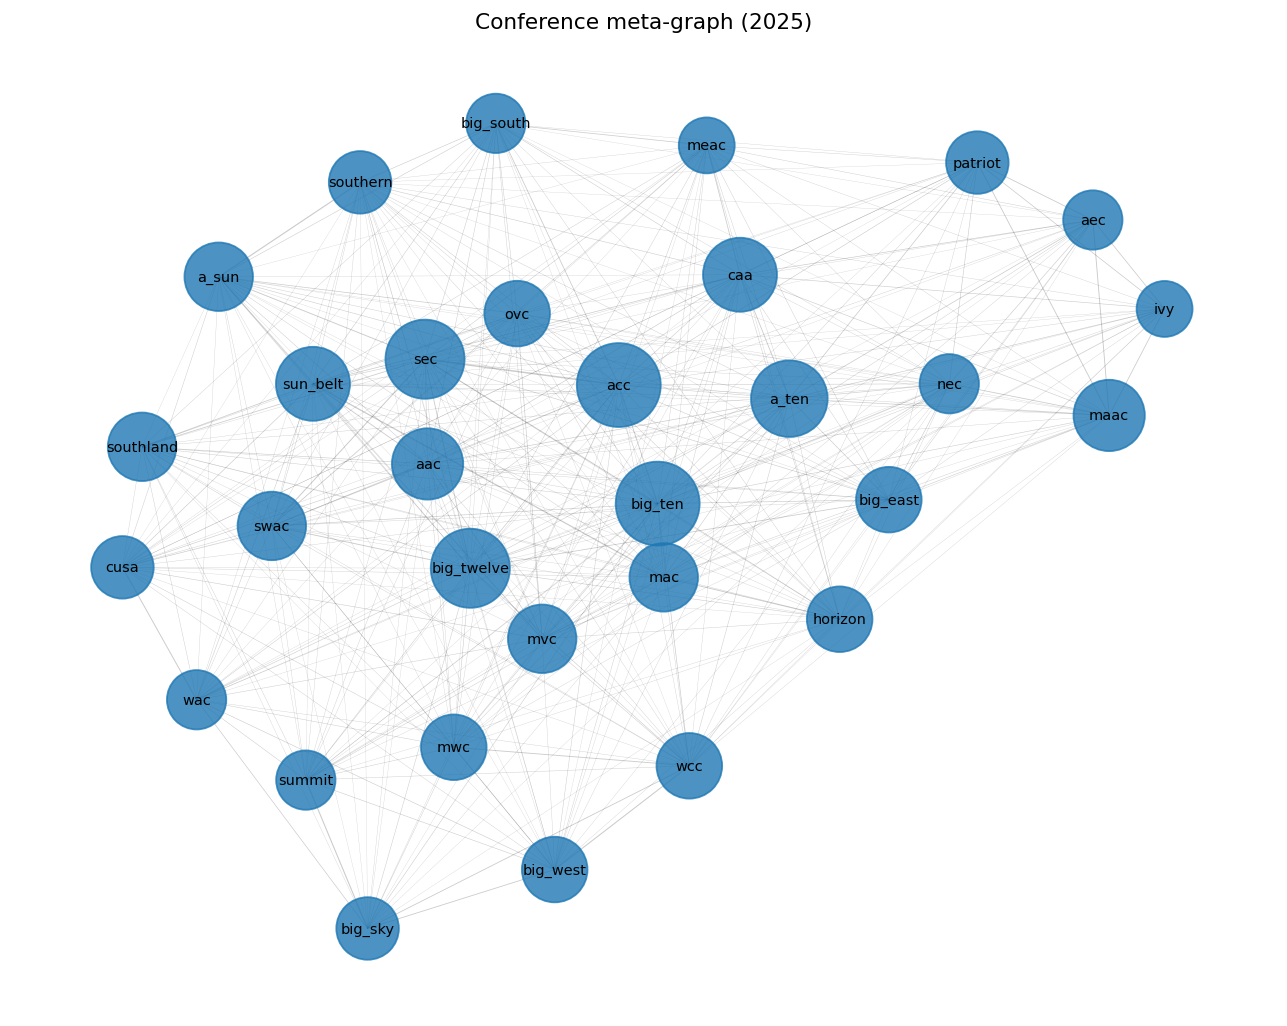

In [18]:
plt.figure(figsize=(10, 8))
pos_c = nx.spring_layout(CG, seed=42, k=0.8, iterations=100, weight="weight")
node_sizes_c = [120 * CG.nodes[n]["size"] for n in CG.nodes()]
edge_widths_c = [0.15 + 0.02 * CG[u][v]["weight"] for u, v in CG.edges()]

nx.draw_networkx_nodes(CG, pos_c, node_size=node_sizes_c, alpha=0.8)
nx.draw_networkx_edges(CG, pos_c, width=edge_widths_c, alpha=0.2)
nx.draw_networkx_labels(CG, pos_c, font_size=8)
plt.axis("off")
finish_figure(f"Conference meta-graph ({SEASON})", f"conference_meta_graph_{SEASON}.png")

## 11. Top teams by centrality
We sort and inspect the most network-central teams for the selected season.

In [19]:
top_weighted_degree = centrality_df.sort_values("WeightedDegree", ascending=False).head(15)
top_betweenness = centrality_df.sort_values("Betweenness", ascending=False).head(15)
top_pagerank = centrality_df.sort_values("PageRank", ascending=False).head(15)

display(top_weighted_degree)
display(top_betweenness)
display(top_pagerank)

save_table(top_weighted_degree, f"top_weighted_degree_{SEASON}")
save_table(top_betweenness, f"top_betweenness_{SEASON}")
save_table(top_pagerank, f"top_pagerank_{SEASON}")

,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
0,1458,Wisconsin,big_ten,28,35,0.005546,0.455458,0.007719
1,1314,North Carolina,acc,29,35,0.004969,0.446494,0.003566
11,1233,Iona,maac,23,34,0.004518,0.414384,0.001761
20,1142,Cal Poly,big_west,21,34,0.002355,0.400221,0.001640
19,1174,Delaware,caa,24,34,0.003003,0.418685,0.001986
18,1337,Pepperdine,wcc,22,34,0.003150,0.410169,0.001457
16,1161,Colorado St,mwc,21,34,0.003982,0.422584,0.006150
15,1257,Louisville,acc,28,34,0.004173,0.440000,0.006060
14,1196,Florida,sec,28,34,0.004177,0.436298,0.019763
13,1166,Creighton,big_east,21,34,0.004264,0.429586,0.006295


,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
21,1390,Stanford,acc,28,33,0.007874,0.443765,0.002603
78,1152,Chicago St,nec,23,32,0.007831,0.457755,0.000606
22,1143,California,acc,28,33,0.006842,0.448148,0.001448
23,1234,Iowa,big_ten,28,33,0.006834,0.454887,0.003087
79,1102,Air Force,mwc,21,32,0.006783,0.437877,0.000751
156,1182,Duquesne,a_ten,26,31,0.006589,0.442683,0.002991
24,1246,Kentucky,sec,28,33,0.006470,0.457755,0.018181
80,1406,Towson,caa,25,32,0.006318,0.445399,0.002490
25,1433,VCU,a_ten,26,33,0.006282,0.437877,0.005000
26,1321,Northwestern,big_ten,28,33,0.006170,0.458913,0.004214


,TeamID,TeamName,Conference,Degree,WeightedDegree,Betweenness,Closeness,PageRank
14,1196,Florida,sec,28,34,0.004177,0.436298,0.019763
39,1120,Auburn,sec,28,33,0.005261,0.457755,0.019432
24,1246,Kentucky,sec,28,33,0.006470,0.457755,0.018181
3,1397,Tennessee,sec,28,34,0.005658,0.444853,0.018163
44,1104,Alabama,sec,28,33,0.005002,0.445399,0.017450
30,1281,Missouri,sec,28,33,0.005710,0.449814,0.012209
127,1401,Texas A&M,sec,28,32,0.003844,0.436298,0.011468
35,1279,Mississippi,sec,28,33,0.005345,0.448702,0.011223
100,1208,Georgia,sec,28,32,0.004851,0.440000,0.010476
31,1277,Michigan St,big_ten,28,33,0.005532,0.457755,0.010062


Saved: outputs/top_weighted_degree_2025.csv
Saved: outputs/top_betweenness_2025.csv
Saved: outputs/top_pagerank_2025.csv


## 12. Bridge-team screening plot
A useful baseline paper figure is a scatter of:
- **weighted degree** on the x-axis,
- **betweenness centrality** on the y-axis.

Teams with unusually high betweenness relative to their weighted degree are good bridge-team candidates.

Saved: outputs/weighted_degree_vs_betweenness_2025.png


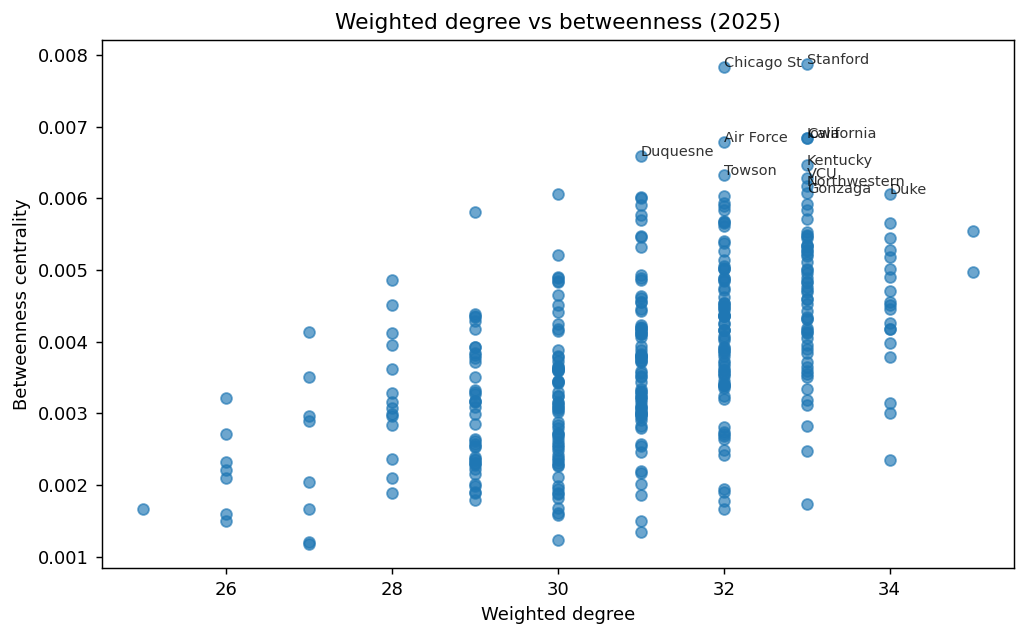

In [20]:
plot_df = centrality_df.copy()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["WeightedDegree"], plot_df["Betweenness"], alpha=0.65)

# annotate a handful of top bridge-like teams
annot_df = plot_df.sort_values(["Betweenness", "WeightedDegree"], ascending=[False, False]).head(12)
for _, row in annot_df.iterrows():
    plt.annotate(
        row["TeamName"],
        (row["WeightedDegree"], row["Betweenness"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Weighted degree")
plt.ylabel("Betweenness centrality")
finish_figure(f"Weighted degree vs betweenness ({SEASON})",
              f"weighted_degree_vs_betweenness_{SEASON}.png")

## 13. Laplacian-based comparability / embeddedness

This section adds the main spectral quantity for the project. We use the **weighted combinatorial Laplacian** of the schedule graph and its pseudoinverse to build a team-level **comparability score**.

Interpretation used in this notebook:

- A team with **lower** Laplacian-based comparability score is more **embedded** in the national schedule network.
- A team with **higher** score is more **peripheral** or structurally harder to compare to the rest of the field.
- This is a graph-based quantity: it depends on where the team sits in the schedule network, not directly on wins/losses.

We also report the **algebraic connectivity** \(\lambda_2\), which summarizes how well connected the season graph is at a global spectral level.


In [21]:

def laplacian_comparability_table(G):
    """Return a team-level table based on the schedule-graph Laplacian pseudoinverse.

    Comparability score:
        MeanResistanceToField = average effective resistance from a team to all other teams.
    Since row sums of L^+ are zero, this is affine-equivalent to diag(L^+), but it is
    slightly easier to interpret as a global 'distance-to-field' summary.

    Lower score  -> more embedded / more comparable
    Higher score -> more peripheral / less comparable
    """
    nodelist = sorted(G.nodes())
    if not nodelist:
        raise ValueError("Graph is empty; cannot compute Laplacian comparability.")

    # Weighted combinatorial Laplacian
    L = nx.laplacian_matrix(G, nodelist=nodelist, weight="weight").astype(float).toarray()
    L = 0.5 * (L + L.T)  # ensure exact symmetry numerically

    eigvals = np.linalg.eigvalsh(L)
    L_pinv = np.linalg.pinv(L)

    lplus_diag = np.diag(L_pinv)
    trace_lplus = float(np.trace(L_pinv))
    n = len(nodelist)

    if n > 1:
        mean_resistance_to_field = (n * lplus_diag + trace_lplus) / (n - 1)
    else:
        mean_resistance_to_field = lplus_diag.copy()

    rows = []
    for idx, node in enumerate(nodelist):
        rows.append({
            "TeamID": int(node),
            "TeamName": G.nodes[node].get("TeamName", str(node)),
            "Conference": G.nodes[node].get("Conference", "unknown"),
            "LplusDiag": float(lplus_diag[idx]),
            "MeanResistanceToField": float(mean_resistance_to_field[idx]),
            "EmbeddednessScore": float(1.0 / (1e-12 + mean_resistance_to_field[idx])),
        })

    df = pd.DataFrame(rows)
    df["ComparabilityRank"] = df["MeanResistanceToField"].rank(method="min", ascending=True).astype(int)
    return df.sort_values("MeanResistanceToField", ascending=True).reset_index(drop=True), L, L_pinv, eigvals


In [22]:

lap_df, L, L_pinv, eigvals = laplacian_comparability_table(G)

algebraic_connectivity = float(eigvals[1]) if len(eigvals) > 1 else np.nan
spectral_summary = pd.DataFrame([{
    "Season": SEASON,
    "Teams": G.number_of_nodes(),
    "Edges": G.number_of_edges(),
    "AlgebraicConnectivity": algebraic_connectivity,
    "TraceLplus": float(np.trace(L_pinv)),
    "MeanResistanceToField": float(lap_df["MeanResistanceToField"].mean()),
    "MedianResistanceToField": float(lap_df["MeanResistanceToField"].median()),
    "MinResistanceToField": float(lap_df["MeanResistanceToField"].min()),
    "MaxResistanceToField": float(lap_df["MeanResistanceToField"].max()),
}])

lap_centrality_df = centrality_df.merge(
    lap_df,
    on=["TeamID", "TeamName", "Conference"],
    how="left"
)

conference_comparability_df = (
    lap_centrality_df.groupby("Conference")
    .agg(
        Teams=("TeamID", "count"),
        MeanResistanceToField=("MeanResistanceToField", "mean"),
        MedianResistanceToField=("MeanResistanceToField", "median"),
        MeanEmbeddednessScore=("EmbeddednessScore", "mean"),
        MeanWeightedDegree=("WeightedDegree", "mean"),
        MeanBetweenness=("Betweenness", "mean"),
    )
    .reset_index()
    .merge(conf_connectivity_df, on="Conference", how="left")
    .sort_values("MeanResistanceToField", ascending=True)
    .reset_index(drop=True)
)

most_embedded_teams = lap_centrality_df.sort_values("MeanResistanceToField", ascending=True).head(15)
most_peripheral_teams = lap_centrality_df.sort_values("MeanResistanceToField", ascending=False).head(15)

display(spectral_summary)
display(most_embedded_teams[[
    "TeamName", "Conference", "MeanResistanceToField", "LplusDiag",
    "WeightedDegree", "Betweenness", "PageRank"
]])
display(most_peripheral_teams[[
    "TeamName", "Conference", "MeanResistanceToField", "LplusDiag",
    "WeightedDegree", "Betweenness", "PageRank"
]])
display(conference_comparability_df.head(15))
display(conference_comparability_df.tail(15))

save_table(spectral_summary, f"spectral_summary_{SEASON}")
save_table(lap_centrality_df, f"laplacian_centrality_table_{SEASON}")
save_table(conference_comparability_df, f"conference_comparability_{SEASON}")


,Season,Teams,Edges,AlgebraicConnectivity,TraceLplus,MeanResistanceToField,MedianResistanceToField,MinResistanceToField,MaxResistanceToField
0,2025,364,4043,4.387753,13.259468,0.073055,0.072927,0.067662,0.081652


,TeamName,Conference,MeanResistanceToField,LplusDiag,WeightedDegree,Betweenness,PageRank
1,North Carolina,acc,0.067662,0.031049,35,0.004969,0.003566
0,Wisconsin,big_ten,0.067701,0.031087,35,0.005546,0.007719
3,Tennessee,sec,0.068341,0.031727,34,0.005658,0.018163
4,Texas,sec,0.068379,0.031764,34,0.005448,0.007226
14,Florida,sec,0.068430,0.031815,34,0.004177,0.019763
2,Duke,acc,0.068555,0.031940,34,0.006057,0.009875
12,Michigan,big_ten,0.068558,0.031943,34,0.004453,0.009031
15,Louisville,acc,0.068628,0.032012,34,0.004173,0.006060
8,Houston,big_twelve,0.068899,0.032282,34,0.004903,0.008667
6,Memphis,aac,0.068958,0.032341,34,0.005177,0.008874


,TeamName,Conference,MeanResistanceToField,LplusDiag,WeightedDegree,Betweenness,PageRank
363,Columbia,ivy,0.081652,0.045000,25,0.001668,0.001172
361,Citadel,southern,0.081237,0.044587,26,0.001597,0.000434
359,Dartmouth,ivy,0.080432,0.043784,26,0.002211,0.001534
358,Oral Roberts,summit,0.080185,0.043538,26,0.002319,0.000743
354,Idaho St,big_sky,0.080081,0.043434,27,0.001212,0.001076
362,Wagner,nec,0.080065,0.043418,26,0.001502,0.000988
360,Brown,ivy,0.080055,0.043408,26,0.002104,0.001591
357,Harvard,ivy,0.079902,0.043255,26,0.002718,0.001620
353,W Carolina,southern,0.079496,0.042851,27,0.001671,0.000639
351,UTRGV,southland,0.079369,0.042724,27,0.002890,0.000925


,Conference,Teams,MeanResistanceToField,MedianResistanceToField,MeanEmbeddednessScore,MeanWeightedDegree,MeanBetweenness,TeamsInSeason,InterconfDegree,InterconfWeightedDegree
0,sec,16,0.069295,0.069145,14.432070,32.875000,0.004919,16,28,208
1,acc,18,0.069790,0.069452,14.331454,32.611111,0.005115,18,30,199
2,big_ten,18,0.069857,0.069437,14.318162,32.500000,0.005526,18,30,197
3,big_twelve,16,0.070071,0.069881,14.272386,32.812500,0.004573,16,28,171
4,a_ten,15,0.071011,0.070942,14.085358,31.733333,0.005178,15,27,176
5,big_east,11,0.071156,0.070993,14.054651,32.818182,0.003819,11,24,121
6,caa,14,0.071598,0.071533,13.970944,31.428571,0.004400,14,26,162
7,aac,13,0.071718,0.071882,13.948395,31.384615,0.004264,13,27,150
8,wcc,11,0.071936,0.071672,13.904419,31.909091,0.004198,11,27,133
9,sun_belt,14,0.072323,0.072313,13.831130,31.000000,0.003767,14,25,156


,Conference,Teams,MeanResistanceToField,MedianResistanceToField,MeanEmbeddednessScore,MeanWeightedDegree,MeanBetweenness,TeamsInSeason,InterconfDegree,InterconfWeightedDegree
16,patriot,10,0.073977,0.073371,13.526805,31.000000,0.002662,10,19,112
17,wac,9,0.074027,0.074226,13.514424,30.111111,0.003886,9,22,111
18,big_south,9,0.074111,0.073821,13.498956,30.000000,0.003435,9,23,110
19,aec,9,0.074180,0.073804,13.484660,30.333333,0.002839,9,20,115
20,horizon,11,0.074269,0.074231,13.469017,31.000000,0.003181,11,28,101
21,big_west,11,0.074466,0.074348,13.434676,31.090909,0.002664,11,22,108
22,nec,9,0.074670,0.074350,13.404992,29.666667,0.004065,9,27,109
23,cusa,10,0.074744,0.074719,13.380853,30.100000,0.003285,10,24,103
24,summit,9,0.075339,0.075552,13.283150,29.444444,0.003571,9,24,105
25,southern,10,0.075759,0.074914,13.213602,29.700000,0.003240,10,28,99


Saved: outputs/spectral_summary_2025.csv
Saved: outputs/laplacian_centrality_table_2025.csv
Saved: outputs/conference_comparability_2025.csv


Saved: outputs/laplacian_comparability_hist_2025.png


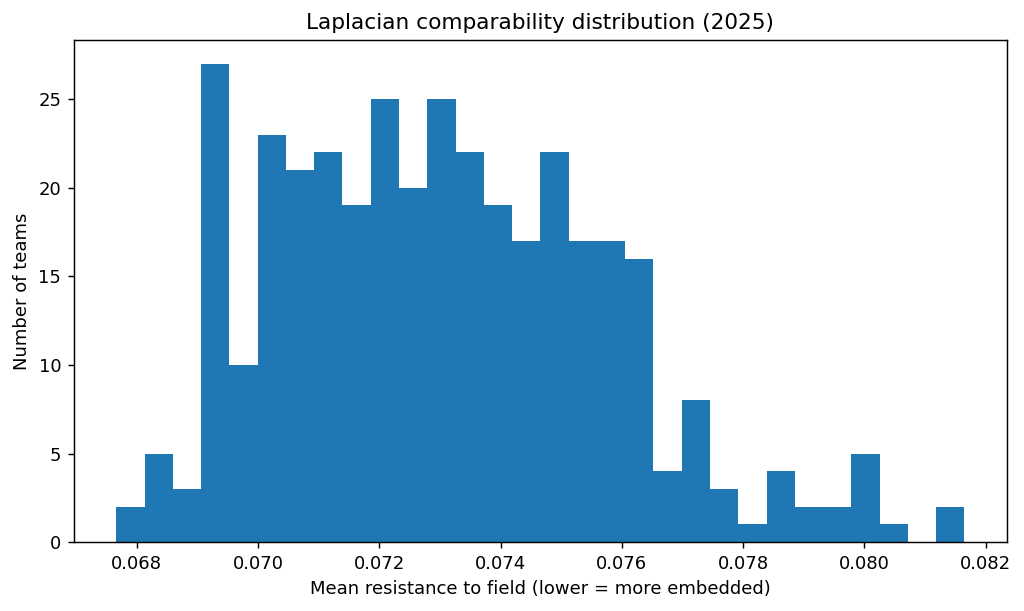

Saved: outputs/weighted_degree_vs_laplacian_2025.png


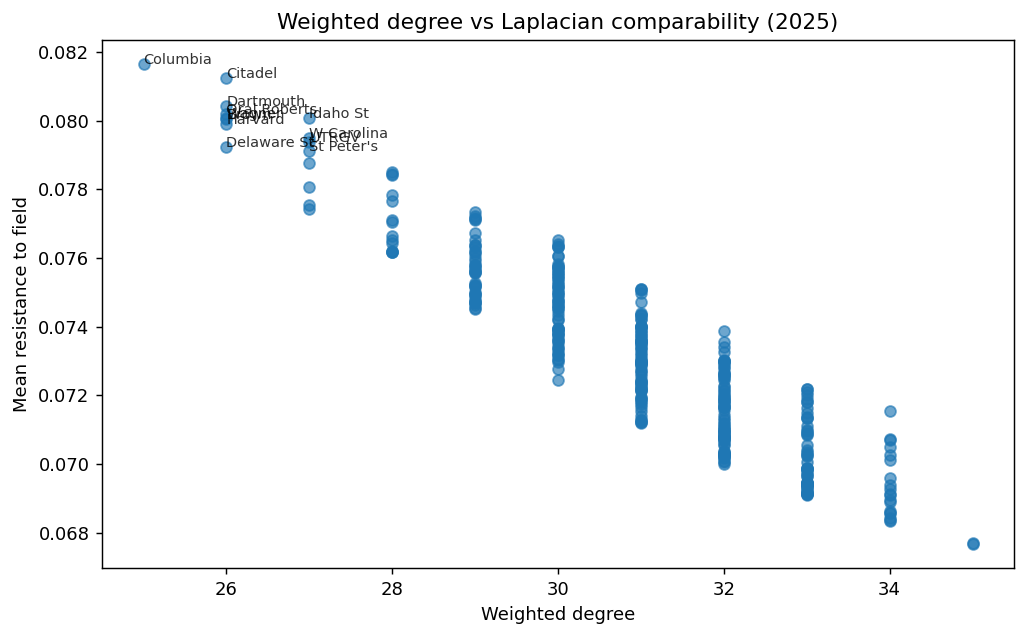

Saved: outputs/betweenness_vs_laplacian_2025.png


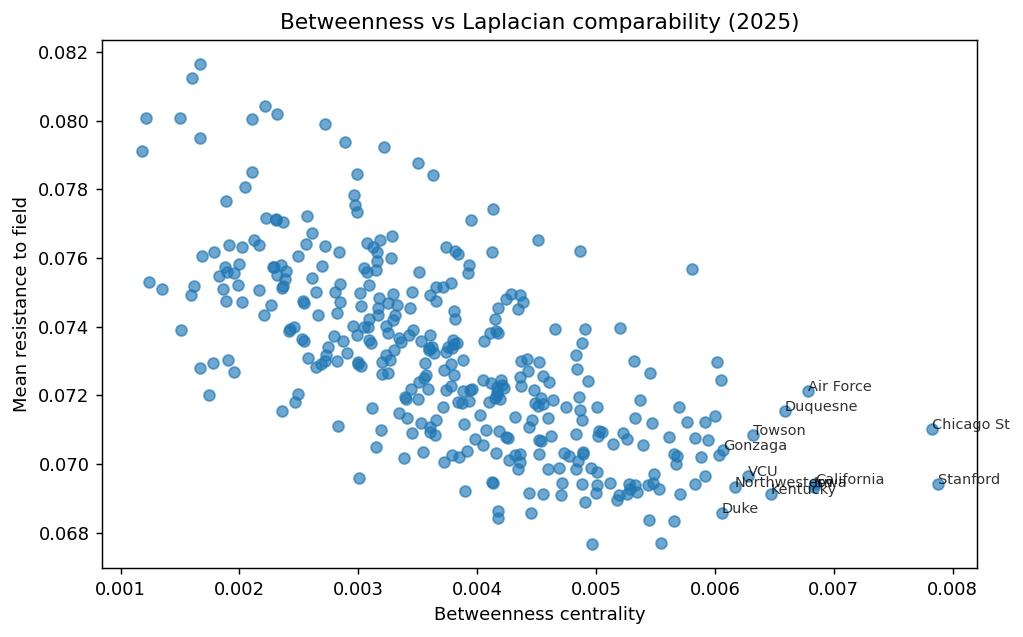

Saved: outputs/conference_comparability_2025.png


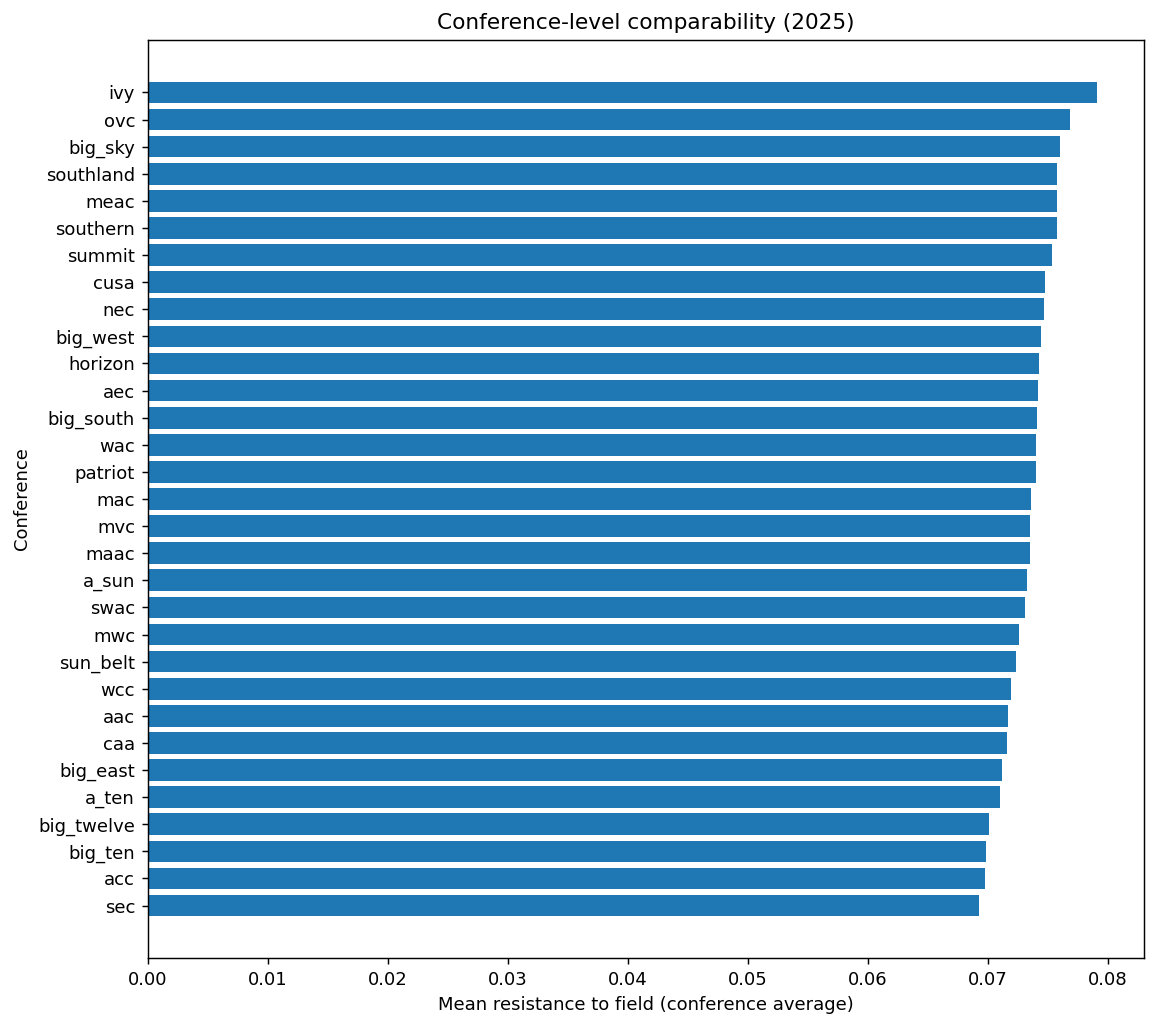

In [23]:

plt.figure(figsize=(8, 4.8))
plt.hist(lap_centrality_df["MeanResistanceToField"], bins=30)
plt.xlabel("Mean resistance to field (lower = more embedded)")
plt.ylabel("Number of teams")
finish_figure(
    f"Laplacian comparability distribution ({SEASON})",
    f"laplacian_comparability_hist_{SEASON}.png"
)

plt.figure(figsize=(8, 5))
plt.scatter(
    lap_centrality_df["WeightedDegree"],
    lap_centrality_df["MeanResistanceToField"],
    alpha=0.65
)

annot_df = lap_centrality_df.sort_values("MeanResistanceToField", ascending=False).head(12)
for _, row in annot_df.iterrows():
    plt.annotate(
        row["TeamName"],
        (row["WeightedDegree"], row["MeanResistanceToField"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Weighted degree")
plt.ylabel("Mean resistance to field")
finish_figure(
    f"Weighted degree vs Laplacian comparability ({SEASON})",
    f"weighted_degree_vs_laplacian_{SEASON}.png"
)

plt.figure(figsize=(8, 5))
plt.scatter(
    lap_centrality_df["Betweenness"],
    lap_centrality_df["MeanResistanceToField"],
    alpha=0.65
)

annot_df = lap_centrality_df.sort_values(
    ["Betweenness", "MeanResistanceToField"],
    ascending=[False, False]
).head(12)
for _, row in annot_df.iterrows():
    plt.annotate(
        row["TeamName"],
        (row["Betweenness"], row["MeanResistanceToField"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Betweenness centrality")
plt.ylabel("Mean resistance to field")
finish_figure(
    f"Betweenness vs Laplacian comparability ({SEASON})",
    f"betweenness_vs_laplacian_{SEASON}.png"
)

plot_conf_df = conference_comparability_df.sort_values("MeanResistanceToField", ascending=True).copy()
plt.figure(figsize=(9, 8))
plt.barh(plot_conf_df["Conference"], plot_conf_df["MeanResistanceToField"])
plt.xlabel("Mean resistance to field (conference average)")
plt.ylabel("Conference")
finish_figure(
    f"Conference-level comparability ({SEASON})",
    f"conference_comparability_{SEASON}.png"
)


## 14. Null-model comparison (Erdős–Rényi and degree-preserving)

This section asks whether the observed schedule topology is genuinely structured, or whether similar patterns would arise in simple random graph baselines.

To stay close to standard network-science null models, we work with the **unweighted schedule topology** here:
- **Erdős–Rényi** baseline with the same number of nodes and approximately the same density.
- **Degree-preserving** baseline using a random simple graph with the same degree sequence as the observed schedule graph.

We then compare the observed graph to the null samples on three quantities that are especially relevant to the course:
- **Average clustering**
- **Average path length on the giant connected component**
- **Conference modularity** under the real conference partition

If the observed graph has much higher modularity and clustering than both null families, that supports the claim that conference organization is a real network feature rather than a generic consequence of graph size or degree heterogeneity.


In [24]:
# Null-model configuration
NULL_SAMPLE_COUNT = 20
NULL_BASE_SEED = 168

def conference_partition_from_graph(G):
    communities = {}
    for node, data in G.nodes(data=True):
        communities.setdefault(data.get("Conference", "unknown"), []).append(node)
    return list(communities.values())

def simple_graph_metrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)
    avg_degree = np.mean([d for _, d in G.degree()]) if n else np.nan
    avg_clustering = nx.average_clustering(G)

    components = list(nx.connected_components(G))
    gcc_nodes = max(components, key=len)
    G_gcc = G.subgraph(gcc_nodes).copy()

    avg_path = nx.average_shortest_path_length(G_gcc) if len(G_gcc) > 1 else np.nan
    gcc_share = len(gcc_nodes) / n if n else np.nan

    conference_partition = conference_partition_from_graph(G)
    conf_modularity = modularity(G, conference_partition, weight=None)

    return {
        "Nodes": n,
        "Edges": m,
        "Density": density,
        "AvgDegree": avg_degree,
        "GCCShare": gcc_share,
        "AvgClustering": avg_clustering,
        "AvgPathLength_GCC": avg_path,
        "ConferenceModularity_Unweighted": conf_modularity,
    }

def relabel_and_copy_attrs(H, nodelist, original_graph):
    mapping = {i: node for i, node in enumerate(nodelist)}
    H = nx.relabel_nodes(H, mapping)

    attrs = {
        node: {
            "TeamName": original_graph.nodes[node].get("TeamName"),
            "Conference": original_graph.nodes[node].get("Conference", "unknown"),
        }
        for node in H.nodes()
    }
    nx.set_node_attributes(H, attrs)
    return H

def sample_er_null_graph(G, seed):
    nodelist = sorted(G.nodes())
    n = len(nodelist)
    m = G.number_of_edges()
    p = 2 * m / (n * (n - 1))

    H = nx.gnp_random_graph(n, p, seed=seed)
    return relabel_and_copy_attrs(H, nodelist, G)

def sample_degree_preserving_null_graph(G, seed, tries=200, max_attempts=5):
    nodelist = sorted(G.nodes())
    degree_sequence = [G.degree(node) for node in nodelist]

    last_err = None
    for attempt in range(max_attempts):
        try_seed = seed + attempt
        try:
            H = nx.random_degree_sequence_graph(degree_sequence, seed=try_seed, tries=tries)
            return relabel_and_copy_attrs(H, nodelist, G)
        except Exception as err:
            last_err = err

    raise RuntimeError(f"Degree-preserving null model failed after {max_attempts} attempts: {last_err}")

def null_model_comparison_table(G, n_samples=20, base_seed=168):
    observed = simple_graph_metrics(G)
    rows = [{"Model": "Observed", "Sample": -1, **observed}]

    for model_name in ["Erdos-Renyi", "Degree-Preserving"]:
        for s in range(n_samples):
            seed = base_seed + 1000 * (1 if model_name == "Erdos-Renyi" else 2) + s

            if model_name == "Erdos-Renyi":
                H = sample_er_null_graph(G, seed=seed)
            else:
                H = sample_degree_preserving_null_graph(G, seed=seed, tries=200)

            rows.append({
                "Model": model_name,
                "Sample": s,
                **simple_graph_metrics(H),
            })

    return pd.DataFrame(rows)

def summarize_null_results(null_df, metrics):
    observed = null_df.loc[null_df["Model"] == "Observed"].iloc[0]
    rows = []

    for model_name in [m for m in null_df["Model"].unique() if m != "Observed"]:
        model_df = null_df.loc[null_df["Model"] == model_name]

        for metric in metrics:
            values = model_df[metric].dropna().to_numpy(dtype=float)
            obs = float(observed[metric])

            null_mean = float(values.mean())
            null_std = float(values.std(ddof=1)) if len(values) > 1 else np.nan
            z_score = (obs - null_mean) / null_std if null_std and not np.isnan(null_std) and null_std > 0 else np.nan

            rows.append({
                "Model": model_name,
                "Metric": metric,
                "Observed": obs,
                "NullMean": null_mean,
                "NullStd": null_std,
                "ZScore_vsNull": z_score,
                "EmpiricalPercentile": float(np.mean(values <= obs)),
                "NullMin": float(values.min()),
                "NullMax": float(values.max()),
            })

    return pd.DataFrame(rows)


In [25]:
null_metrics = [
    "AvgClustering",
    "AvgPathLength_GCC",
    "ConferenceModularity_Unweighted",
]

null_df = null_model_comparison_table(
    G,
    n_samples=NULL_SAMPLE_COUNT,
    base_seed=NULL_BASE_SEED,
)

null_summary_df = summarize_null_results(null_df, metrics=null_metrics)

display(null_summary_df.sort_values(["Metric", "Model"]).reset_index(drop=True))

save_table(null_df, f"null_model_samples_{SEASON}")
save_table(null_summary_df, f"null_model_summary_{SEASON}")


,Model,Metric,Observed,NullMean,NullStd,ZScore_vsNull,EmpiricalPercentile,NullMin,NullMax
0,Degree-Preserving,AvgClustering,0.310107,0.058441,0.001437,175.089076,1.0,0.055729,0.061082
1,Erdos-Renyi,AvgClustering,0.310107,0.061466,0.001789,138.980079,1.0,0.058041,0.065166
2,Degree-Preserving,AvgPathLength_GCC,2.374868,2.176604,0.001438,137.903374,1.0,2.174961,2.179533
3,Erdos-Renyi,AvgPathLength_GCC,2.374868,2.178515,0.012074,16.262637,1.0,2.162580,2.209291
4,Degree-Preserving,ConferenceModularity_Unweighted,0.472568,-0.002537,0.002772,171.389805,1.0,-0.007026,0.004599
5,Erdos-Renyi,ConferenceModularity_Unweighted,0.472568,-0.002658,0.002522,188.451747,1.0,-0.006713,0.001263


Saved: outputs/null_model_samples_2025.csv
Saved: outputs/null_model_summary_2025.csv


Saved: outputs/null_model_comparison_boxplots_2025.png


/var/folders/tz/hbtlmw5d64b1hf0gct298xmc0000gn/T/ipykernel_23713/1954843259.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=model_order, showfliers=False)
/var/folders/tz/hbtlmw5d64b1hf0gct298xmc0000gn/T/ipykernel_23713/1954843259.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=model_order, showfliers=False)
/var/folders/tz/hbtlmw5d64b1hf0gct298xmc0000gn/T/ipykernel_23713/1954843259.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=model_order, showfliers=False)


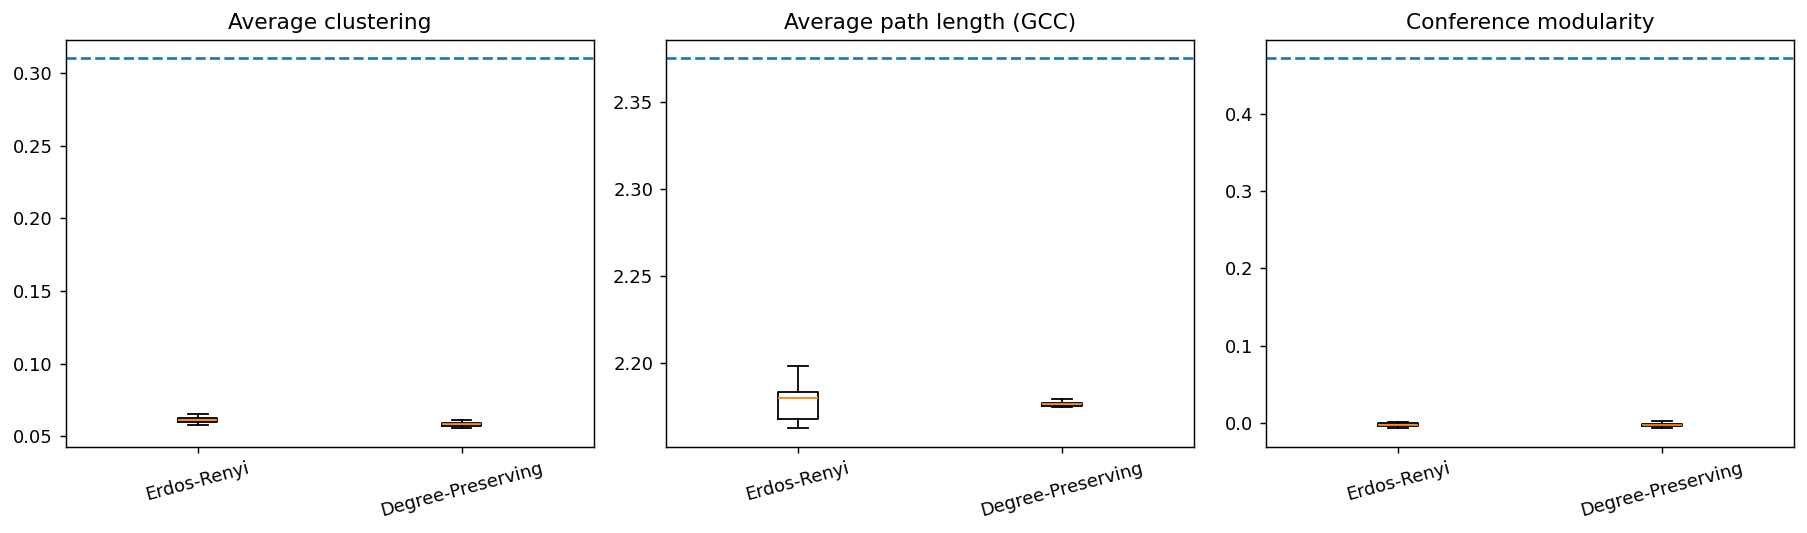

In [26]:
metric_labels = {
    "AvgClustering": "Average clustering",
    "AvgPathLength_GCC": "Average path length (GCC)",
    "ConferenceModularity_Unweighted": "Conference modularity",
}

observed_row = null_df.loc[null_df["Model"] == "Observed"].iloc[0]
model_order = ["Erdos-Renyi", "Degree-Preserving"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, metric in zip(axes, null_metrics):
    data = [
        null_df.loc[null_df["Model"] == model_name, metric].to_numpy(dtype=float)
        for model_name in model_order
    ]
    ax.boxplot(data, labels=model_order, showfliers=False)
    ax.axhline(float(observed_row[metric]), linestyle="--", linewidth=1.5)
    ax.set_title(metric_labels[metric])
    ax.tick_params(axis="x", rotation=15)

finish_figure(filename=f"null_model_comparison_boxplots_{SEASON}.png")


In [27]:
null_summary_pivot = (
    null_summary_df.pivot(index="Metric", columns="Model", values=["Observed", "NullMean", "ZScore_vsNull", "EmpiricalPercentile"])
    .sort_index()
)

display(null_summary_pivot)
save_table(null_summary_pivot.reset_index(), f"null_model_summary_pivot_{SEASON}")


Observed              \
Model                           Degree-Preserving Erdos-Renyi   
Metric                                                          
AvgClustering                            0.310107    0.310107   
AvgPathLength_GCC                        2.374868    2.374868   
ConferenceModularity_Unweighted          0.472568    0.472568   

                                         NullMean              \
Model                           Degree-Preserving Erdos-Renyi   
Metric                                                          
AvgClustering                            0.058441    0.061466   
AvgPathLength_GCC                        2.176604    2.178515   
ConferenceModularity_Unweighted         -0.002537   -0.002658   

                                    ZScore_vsNull              \
Model                           Degree-Preserving Erdos-Renyi   
Metric                                                          
AvgClustering                          175.089076  138.980079   
AvgPathLength_GCC                      137.903374   16.262637   
ConferenceModularity_Unweighted        171.389805  188.451747   

                                EmpiricalPercentile              
Model                             Degree-Preserving Erdos-Renyi  
Metric                                                           
AvgClustering                                   1.0         1.0  
AvgPathLength_GCC                               1.0         1.0  
ConferenceModularity_Unweighted                 1.0         1.0

Saved: outputs/null_model_summary_pivot_2025.csv


## 15. Updated interpretation notes for the paper draft

At this point, the notebook supports four layers of results:

1. **Community structure:** the NCAA schedule graph is strongly modular along conference lines.  
2. **Bridge structure:** some teams and conferences are disproportionately important for connecting those communities.  
3. **Spectral comparability:** Laplacian-based scores quantify which teams are most embedded in, or most peripheral to, the national schedule network.  
4. **Null-model comparison:** the observed schedule graph can be compared to Erdős–Rényi and degree-preserving baselines to show that its clustering and conference modularity are not generic random-graph artifacts.

This gives the project a clear progression from descriptive network structure to a more mathematical notion of global comparability, and then to a baseline-vs-null argument that the structure is genuinely non-random.


## 16. Suggested next notebook / next section

The strongest next extension after the null-model section would be one of these:

- **Detected communities vs. real conferences:** compare algorithmic community detection to the known conference partition.
- **Conference-level bridge dependence:** quantify whether a few teams carry a disproportionate share of each conference's cross-conference connectivity.
- **Robustness with detailed results:** use score margin or location-aware variants from the detailed-results file.

For the final report, we will likely keep only the most compact and persuasive subset of the notebook outputs.



## 17. Multi-year hypothesis tests (expanded notebook)

This version expands the earlier one-season hypothesis section in two ways:

1. it runs the hypothesis suite across **multiple seasons** so the project has a much larger evidence base; and
2. it adds a couple of extra hypothesis checks that focus on **conference-pair comparability**, not just team-level prediction.

We still begin with **conference labels as the cluster proxy** so the code stays interpretable. That should be read as a practical first pass, not the final network-science endpoint.

### Hypotheses implemented here

- **H1:** Within-cluster transitive predictions are more accurate than cross-cluster transitive predictions.
- **H2:** A team + conference-offset Bradley–Terry model improves held-out cross-cluster prediction relative to a team-only Bradley–Terry model.
- **H3:** More bridge redundancy is associated with lower uncertainty in estimated conference-offset differences.
- **H4:** Conference pairs with more bridge redundancy are easier to predict in held-out cross-cluster games.
- **H5:** Teams from more isolated conferences are more likely to have larger held-out cross-cluster errors under a conventional baseline model.
- **H6:** Conference-offset modeling helps more on **hard-to-calibrate conference pairs** (pairs with higher offset uncertainty / weaker bridge structure).

### Split design

We keep the **stratified random holdout** idea from the prior notebook:

- hold out a larger fraction of **cross-conference** games,
- hold out a smaller fraction of **within-conference** games,
- fit models on the remainder.

That gives H2, H4, H5, and H6 a genuinely usable cross-conference test set.


In [28]:

# Multi-year hypothesis configuration
RANDOM_SEED = 168
TEST_FRAC_CROSS = 0.30
TEST_FRAC_WITHIN = 0.12
MIN_H1_SUPPORT = 1
BT_MAXITER = 500
BT_EPS = 1e-9

# By default this version uses all seasons with conference labels.
# For a faster first run, set SEASON_LIMIT to something like 8 or 10.
SEASON_LIMIT = 10
HYPOTHESIS_SEASONS = valid_seasons if SEASON_LIMIT is None else valid_seasons[-SEASON_LIMIT:]

from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import spearmanr

print(f"Running expanded hypothesis suite on {len(HYPOTHESIS_SEASONS)} seasons: {HYPOTHESIS_SEASONS[0]} to {HYPOTHESIS_SEASONS[-1]}")


Running expanded hypothesis suite on 10 seasons: 2017 to 2026


In [29]:

def _sample_test_indices(index_values, frac, rng):
    index_values = np.asarray(index_values)
    if len(index_values) == 0 or frac <= 0:
        return np.array([], dtype=index_values.dtype)
    n_test = int(round(len(index_values) * frac))
    n_test = max(1, n_test)
    n_test = min(n_test, len(index_values))
    return np.sort(rng.choice(index_values, size=n_test, replace=False))


def prepare_train_test_games(
    season,
    reg_df=reg_compact,
    conf_df=team_confs,
    cross_test_frac=TEST_FRAC_CROSS,
    within_test_frac=TEST_FRAC_WITHIN,
    random_seed=RANDOM_SEED,
):
    """Create a stratified random holdout with enough cross-conference games to test bridge ideas."""
    games = reg_df.loc[reg_df["Season"] == season].copy().reset_index(drop=True)
    confs = conf_df.loc[conf_df["Season"] == season, ["TeamID", "ConfAbbrev"]].drop_duplicates()
    conf_map = confs.set_index("TeamID")["ConfAbbrev"].to_dict()

    games["WConf"] = games["WTeamID"].map(conf_map).fillna("unknown")
    games["LConf"] = games["LTeamID"].map(conf_map).fillna("unknown")
    games["SameConf"] = games["WConf"] == games["LConf"]
    games["GameType"] = np.where(games["SameConf"], "Within-cluster", "Cross-cluster")

    rng = np.random.default_rng(random_seed)
    cross_idx = games.index[~games["SameConf"]].to_numpy()
    within_idx = games.index[games["SameConf"]].to_numpy()

    test_cross_idx = _sample_test_indices(cross_idx, cross_test_frac, rng)
    test_within_idx = _sample_test_indices(within_idx, within_test_frac, rng)
    test_idx = np.sort(np.concatenate([test_cross_idx, test_within_idx]))

    games["Split"] = "train"
    games.loc[test_idx, "Split"] = "test"

    train_games = games.loc[games["Split"] == "train"].copy()
    test_games = games.loc[games["Split"] == "test"].copy()

    split_summary = (
        games.groupby(["Split", "GameType"])
        .size()
        .rename("N")
        .reset_index()
        .pivot(index="Split", columns="GameType", values="N")
        .fillna(0)
        .astype(int)
        .reset_index()
    )
    split_summary["Season"] = season
    return games, train_games, test_games, conf_map, split_summary


def attach_conf_pair_columns(df, wconf_col="WConf", lconf_col="LConf"):
    out = df.copy()
    out["Conf1"] = out[[wconf_col, lconf_col]].min(axis=1)
    out["Conf2"] = out[[wconf_col, lconf_col]].max(axis=1)
    return out


def conference_pair_prediction_table(test_pred_df):
    cross = test_pred_df.loc[~test_pred_df["SameConf"]].copy()
    if cross.empty:
        return pd.DataFrame(columns=[
            "Conf1", "Conf2", "N", "PairLogLoss_TeamOnly", "PairLogLoss_TeamCluster",
            "PairBrier_TeamOnly", "PairBrier_TeamCluster", "LogLoss_Improvement", "Brier_Improvement"
        ])
    cross = attach_conf_pair_columns(cross)
    out = (
        cross.groupby(["Conf1", "Conf2"])
        .agg(
            N=("Conf1", "size"),
            PairLogLoss_TeamOnly=("LogLoss_TeamOnly", "mean"),
            PairLogLoss_TeamCluster=("LogLoss_TeamCluster", "mean"),
            PairBrier_TeamOnly=("Brier_TeamOnly", "mean"),
            PairBrier_TeamCluster=("Brier_TeamCluster", "mean"),
        )
        .reset_index()
    )
    out["LogLoss_Improvement"] = out["PairLogLoss_TeamOnly"] - out["PairLogLoss_TeamCluster"]
    out["Brier_Improvement"] = out["PairBrier_TeamOnly"] - out["PairBrier_TeamCluster"]
    return out


def team_misevaluation_table(cross_test_pred_df, conf_isolation_df):
    team_error_rows = []
    for _, row in cross_test_pred_df.iterrows():
        for team_col, conf_col, name_col in [
            ("WTeamID", "WConf", "WTeamName"),
            ("LTeamID", "LConf", "LTeamName"),
        ]:
            team_error_rows.append({
                "TeamID": int(row[team_col]),
                "TeamName": row[name_col],
                "ConfAbbrev": row[conf_col],
                "LogLoss_TeamOnly": row["LogLoss_TeamOnly"],
                "Brier_TeamOnly": row["Brier_TeamOnly"],
            })
    if not team_error_rows:
        return pd.DataFrame(columns=[
            "TeamID", "TeamName", "ConfAbbrev", "CrossTestGames", "MeanLogLoss_TeamOnly",
            "MeanBrier_TeamOnly", "IsolationScore", "BridgeFraction", "DistinctOutsideConfs"
        ])

    team_error_df = pd.DataFrame(team_error_rows)
    out = (
        team_error_df
        .groupby(["TeamID", "TeamName", "ConfAbbrev"])
        .agg(
            CrossTestGames=("TeamID", "size"),
            MeanLogLoss_TeamOnly=("LogLoss_TeamOnly", "mean"),
            MeanBrier_TeamOnly=("Brier_TeamOnly", "mean"),
        )
        .reset_index()
        .merge(
            conf_isolation_df[["ConfAbbrev", "IsolationScore", "BridgeFraction", "DistinctOutsideConfs"]],
            on="ConfAbbrev",
            how="left",
        )
    )
    return out


def safe_spearman(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    mask = x.notna() & y.notna()
    if mask.sum() < 3 or x[mask].nunique() < 2 or y[mask].nunique() < 2:
        return np.nan, np.nan, int(mask.sum())
    res = spearmanr(x[mask], y[mask], nan_policy="omit")
    return float(res.statistic), float(res.pvalue), int(mask.sum())


### Restored hypothesis helper functions
This cell restores the H1/H2/H3/H5 helper functions required by the multi-year suite.

In [30]:

def _sample_test_indices(index_values, frac, rng):
    index_values = np.asarray(index_values)
    if len(index_values) == 0 or frac <= 0:
        return np.array([], dtype=index_values.dtype)
    n_test = int(round(len(index_values) * frac))
    n_test = max(1, n_test)
    n_test = min(n_test, len(index_values))
    return np.sort(rng.choice(index_values, size=n_test, replace=False))


def prepare_train_test_games(
    season,
    reg_df=reg_compact,
    conf_df=team_confs,
    cross_test_frac=TEST_FRAC_CROSS,
    within_test_frac=TEST_FRAC_WITHIN,
    random_seed=RANDOM_SEED,
):
    """Create a stratified random holdout with enough cross-conference games to test H2/H5.

    The split is done separately for same-conference and cross-conference games so the test
    set contains a usable number of bridge games instead of being overwhelmed by late-season
    conference play.
    """
    games = reg_df.loc[reg_df["Season"] == season].copy().reset_index(drop=True)
    confs = conf_df.loc[conf_df["Season"] == season, ["TeamID", "ConfAbbrev"]].drop_duplicates()
    conf_map = confs.set_index("TeamID")["ConfAbbrev"].to_dict()

    games["WConf"] = games["WTeamID"].map(conf_map).fillna("unknown")
    games["LConf"] = games["LTeamID"].map(conf_map).fillna("unknown")
    games["SameConf"] = games["WConf"] == games["LConf"]
    games["GameType"] = np.where(games["SameConf"], "Within-cluster", "Cross-cluster")

    rng = np.random.default_rng(random_seed)
    cross_idx = games.index[~games["SameConf"]].to_numpy()
    within_idx = games.index[games["SameConf"]].to_numpy()

    test_cross_idx = _sample_test_indices(cross_idx, cross_test_frac, rng)
    test_within_idx = _sample_test_indices(within_idx, within_test_frac, rng)
    test_idx = np.sort(np.concatenate([test_cross_idx, test_within_idx]))

    games["Split"] = "train"
    games.loc[test_idx, "Split"] = "test"

    train_games = games.loc[games["Split"] == "train"].copy()
    test_games = games.loc[games["Split"] == "test"].copy()

    split_summary = pd.DataFrame([
        {
            "Season": season,
            "TotalGames": len(games),
            "TrainGames": len(train_games),
            "TestGames": len(test_games),
            "CrossConfTrain": int((~train_games["SameConf"]).sum()),
            "CrossConfTest": int((~test_games["SameConf"]).sum()),
            "WithinConfTrain": int((train_games["SameConf"]).sum()),
            "WithinConfTest": int((test_games["SameConf"]).sum()),
            "CrossTestFrac": cross_test_frac,
            "WithinTestFrac": within_test_frac,
            "RandomSeed": random_seed,
        }
    ])
    return games, train_games, test_games, conf_map, split_summary


def build_win_counts(train_games):
    """Return directed win counts and total meeting counts from train games."""
    win_counts = {}
    pair_totals = {}
    for _, row in train_games.iterrows():
        w = int(row["WTeamID"])
        l = int(row["LTeamID"])
        win_counts[(w, l)] = win_counts.get((w, l), 0) + 1
        pair = tuple(sorted((w, l)))
        pair_totals[pair] = pair_totals.get(pair, 0) + 1
    return win_counts, pair_totals


def build_h1_candidate_table(train_games, test_games, conf_map, min_support=MIN_H1_SUPPORT):
    """Build held-out direct matchups with train-time 2-hop transitive support.

    For each held-out direct matchup (A, C), we search for intermediates B in the training graph such that:
        A beat B in train, and B beat C in train.
    The transitive prediction is therefore A > C.
    """
    win_counts, _ = build_win_counts(train_games)

    out_neighbors = {}
    for (u, v), count in win_counts.items():
        out_neighbors.setdefault(u, set()).add(v)

    rows = []
    for _, row in test_games.iterrows():
        winner = int(row["WTeamID"])
        loser = int(row["LTeamID"])
        for a, c, actual in [(winner, loser, 1), (loser, winner, 0)]:
            a_out = out_neighbors.get(a, set())
            c_in_support = [b for b in a_out if (b, c) in win_counts]
            if len(c_in_support) < min_support:
                continue
            same_cluster = conf_map.get(a, "unknown") == conf_map.get(c, "unknown")
            rows.append({
                "TeamA": a,
                "TeamC": c,
                "TeamAName": team_name_map.get(a, str(a)),
                "TeamCName": team_name_map.get(c, str(c)),
                "Actual_A_Beats_C": actual,
                "SupportCount": len(c_in_support),
                "SameCluster": same_cluster,
                "AConf": conf_map.get(a, "unknown"),
                "CConf": conf_map.get(c, "unknown"),
            })
    return pd.DataFrame(rows)


def fit_bradley_terry_team_only(train_games, team_ids, maxiter=BT_MAXITER):
    team_ids = sorted(team_ids)
    team_to_idx = {tid: i for i, tid in enumerate(team_ids)}
    games = [(team_to_idx[int(r.WTeamID)], team_to_idx[int(r.LTeamID)]) for r in train_games.itertuples()]

    def unpack(x_free):
        return np.concatenate(([0.0], np.asarray(x_free)))

    def objective(x_free):
        theta = unpack(x_free)
        nll = 0.0
        for wi, li in games:
            nll += np.logaddexp(0.0, theta[li] - theta[wi])
        return float(nll)

    x0 = np.zeros(len(team_ids) - 1)
    res = minimize(objective, x0, method="L-BFGS-B", options={"maxiter": maxiter})
    theta = unpack(res.x)
    return {
        "team_ids": team_ids,
        "team_to_idx": team_to_idx,
        "theta": theta,
        "opt_result": res,
    }


def fit_bradley_terry_team_cluster(train_games, team_ids, conf_map, maxiter=BT_MAXITER):
    team_ids = sorted(team_ids)
    confs = sorted({conf_map.get(tid, "unknown") for tid in team_ids})

    team_to_idx = {tid: i for i, tid in enumerate(team_ids)}
    conf_to_idx = {c: i for i, c in enumerate(confs)}
    games = [
        (team_to_idx[int(r.WTeamID)], team_to_idx[int(r.LTeamID)], conf_to_idx[conf_map.get(int(r.WTeamID), "unknown")], conf_to_idx[conf_map.get(int(r.LTeamID), "unknown")])
        for r in train_games.itertuples()
    ]

    n_team_free = max(0, len(team_ids) - 1)
    n_conf_free = max(0, len(confs) - 1)

    def unpack(x):
        x = np.asarray(x)
        theta = np.concatenate(([0.0], x[:n_team_free])) if len(team_ids) else np.array([])
        alpha = np.concatenate(([0.0], x[n_team_free:n_team_free + n_conf_free])) if len(confs) else np.array([])
        return theta, alpha

    def objective(x):
        theta, alpha = unpack(x)
        nll = 0.0
        for wi, li, wc, lc in games:
            logit = (theta[wi] + alpha[wc]) - (theta[li] + alpha[lc])
            nll += np.logaddexp(0.0, -logit)
        return float(nll)

    x0 = np.zeros(n_team_free + n_conf_free)
    res = minimize(objective, x0, method="L-BFGS-B", options={"maxiter": maxiter})
    theta, alpha = unpack(res.x)
    return {
        "team_ids": team_ids,
        "team_to_idx": team_to_idx,
        "theta": theta,
        "confs": confs,
        "conf_to_idx": conf_to_idx,
        "alpha": alpha,
        "opt_result": res,
    }


def add_prediction_columns(test_games, team_only_fit, team_cluster_fit, conf_map):
    rows = []
    for r in test_games.itertuples():
        w = int(r.WTeamID)
        l = int(r.LTeamID)
        if w not in team_only_fit["team_to_idx"] or l not in team_only_fit["team_to_idx"]:
            continue

        wi = team_only_fit["team_to_idx"][w]
        li = team_only_fit["team_to_idx"][l]
        theta0 = team_only_fit["theta"]
        p_team_only = float(expit(theta0[wi] - theta0[li]))

        wc = team_cluster_fit["conf_to_idx"][conf_map.get(w, "unknown")]
        lc = team_cluster_fit["conf_to_idx"][conf_map.get(l, "unknown")]
        theta1 = team_cluster_fit["theta"]
        alpha1 = team_cluster_fit["alpha"]
        p_team_cluster = float(expit((theta1[wi] + alpha1[wc]) - (theta1[li] + alpha1[lc])))

        rows.append({
            "WTeamID": w,
            "LTeamID": l,
            "WTeamName": team_name_map.get(w, str(w)),
            "LTeamName": team_name_map.get(l, str(l)),
            "WConf": conf_map.get(w, "unknown"),
            "LConf": conf_map.get(l, "unknown"),
            "SameConf": conf_map.get(w, "unknown") == conf_map.get(l, "unknown"),
            "PredProb_Wins_TeamOnly": p_team_only,
            "PredProb_Wins_TeamCluster": p_team_cluster,
            "LogLoss_TeamOnly": -np.log(np.clip(p_team_only, BT_EPS, 1 - BT_EPS)),
            "LogLoss_TeamCluster": -np.log(np.clip(p_team_cluster, BT_EPS, 1 - BT_EPS)),
            "Brier_TeamOnly": (1.0 - p_team_only) ** 2,
            "Brier_TeamCluster": (1.0 - p_team_cluster) ** 2,
        })
    return pd.DataFrame(rows)


def approximate_bt_hessian_team_cluster(train_games, fit_obj, conf_map):
    team_to_idx = fit_obj["team_to_idx"]
    conf_to_idx = fit_obj["conf_to_idx"]
    theta = fit_obj["theta"]
    alpha = fit_obj["alpha"]

    p_team = len(theta)
    p_conf = len(alpha)
    dim = p_team + p_conf
    H = np.zeros((dim, dim), dtype=float)

    for r in train_games.itertuples():
        w = int(r.WTeamID)
        l = int(r.LTeamID)
        wi = team_to_idx[w]
        li = team_to_idx[l]
        wc = conf_to_idx[conf_map.get(w, "unknown")]
        lc = conf_to_idx[conf_map.get(l, "unknown")]

        z = (theta[wi] + alpha[wc]) - (theta[li] + alpha[lc])
        p = float(expit(z))
        weight = p * (1.0 - p)

        v = np.zeros(dim, dtype=float)
        v[wi] += 1.0
        v[li] -= 1.0
        v[p_team + wc] += 1.0
        v[p_team + lc] -= 1.0
        H += weight * np.outer(v, v)

    cov = np.linalg.pinv(H)
    return H, cov


def conference_bridge_table(train_games):
    rows = []
    inter = train_games.loc[train_games["WConf"] != train_games["LConf"]].copy()
    if inter.empty:
        return pd.DataFrame(columns=["Conf1", "Conf2", "BridgeGames", "DistinctBridgeTeams", "TeamEntropy"])

    inter["Conf1"] = inter[["WConf", "LConf"]].min(axis=1)
    inter["Conf2"] = inter[["WConf", "LConf"]].max(axis=1)
    for (c1, c2), grp in inter.groupby(["Conf1", "Conf2"]):
        team_counts = pd.concat([grp["WTeamID"], grp["LTeamID"]]).value_counts()
        probs = team_counts / team_counts.sum()
        entropy = float(-(probs * np.log(probs)).sum()) if len(probs) else np.nan
        rows.append({
            "Conf1": c1,
            "Conf2": c2,
            "BridgeGames": int(len(grp)),
            "DistinctBridgeTeams": int(team_counts.index.nunique()),
            "TeamEntropy": entropy,
        })
    return pd.DataFrame(rows).sort_values(["BridgeGames", "DistinctBridgeTeams"], ascending=False)


def conference_offset_uncertainty_table(fit_obj, cov):
    confs = fit_obj["confs"]
    p_team = len(fit_obj["theta"])
    rows = []
    for i in range(len(confs)):
        for j in range(i + 1, len(confs)):
            ii = p_team + i
            jj = p_team + j
            var_diff = cov[ii, ii] + cov[jj, jj] - 2.0 * cov[ii, jj]
            rows.append({
                "Conf1": confs[i],
                "Conf2": confs[j],
                "OffsetDiff": float(fit_obj["alpha"][i] - fit_obj["alpha"][j]),
                "SE_OffsetDiff": float(np.sqrt(max(var_diff, 0.0))),
                "Var_OffsetDiff": float(max(var_diff, 0.0)),
            })
    return pd.DataFrame(rows)


def conference_isolation_table(train_games, confs_season):
    conf_sizes = confs_season.groupby("ConfAbbrev")["TeamID"].nunique().rename("Teams")
    within = train_games.loc[train_games["WConf"] == train_games["LConf"]]
    between = train_games.loc[train_games["WConf"] != train_games["LConf"]]

    within_counts = pd.concat([within["WConf"], within["LConf"]]).value_counts().rename("WithinGames")
    between_counts = pd.concat([between["WConf"], between["LConf"]]).value_counts().rename("BetweenGames")

    outside_conf_counts = {}
    for conf, grp in pd.concat([
        between[["WConf", "LConf"]].rename(columns={"WConf": "Conf", "LConf": "Other"}),
        between[["LConf", "WConf"]].rename(columns={"LConf": "Conf", "WConf": "Other"}),
    ]).groupby("Conf"):
        outside_conf_counts[conf] = grp["Other"].nunique()

    out = pd.DataFrame(index=sorted(set(confs_season["ConfAbbrev"])))
    out = out.join(conf_sizes, how="left")
    out = out.join(within_counts, how="left").join(between_counts, how="left")
    out = out.fillna(0)
    out["DistinctOutsideConfs"] = out.index.map(lambda c: outside_conf_counts.get(c, 0))
    out["TotalIncidenceGames"] = out["WithinGames"] + out["BetweenGames"]
    out["BridgeFraction"] = np.where(out["TotalIncidenceGames"] > 0, out["BetweenGames"] / out["TotalIncidenceGames"], 0.0)
    out["IsolationScore"] = 1.0 - out["BridgeFraction"]
    return out.reset_index().rename(columns={"index": "ConfAbbrev"}).sort_values("IsolationScore", ascending=False)


In [31]:

# Run the full multi-year hypothesis suite
split_rows = []
h1_rows = []
h2_rows = []
h3_rows = []
h4_rows = []
h5_rows = []
offset_rows = []
season_failures = []

for season in HYPOTHESIS_SEASONS:
    try:
        print(f"Running season {season}...")
        season_seed = RANDOM_SEED + int(season)
        all_games_season, train_games, test_games, conf_map_train, split_summary = prepare_train_test_games(
            season,
            cross_test_frac=TEST_FRAC_CROSS,
            within_test_frac=TEST_FRAC_WITHIN,
            random_seed=season_seed,
        )
        split_rows.append(split_summary)

        confs_season_loop = team_confs.loc[team_confs["Season"] == season, ["TeamID", "ConfAbbrev"]].drop_duplicates()
        team_ids_season = sorted(set(all_games_season["WTeamID"]).union(set(all_games_season["LTeamID"])))

        # H1
        h1_candidates = build_h1_candidate_table(train_games, test_games, conf_map_train, min_support=MIN_H1_SUPPORT)
        if not h1_candidates.empty:
            h1_candidates["Season"] = season
            h1_candidates["TransitiveCorrect"] = h1_candidates["Actual_A_Beats_C"] == 1
            h1_rows.append(h1_candidates)

        # H2 model fits and test predictions
        team_only_fit = fit_bradley_terry_team_only(train_games, team_ids_season)
        team_cluster_fit = fit_bradley_terry_team_cluster(train_games, team_ids_season, conf_map_train)
        test_pred_df = add_prediction_columns(test_games, team_only_fit, team_cluster_fit, conf_map_train)
        if not test_pred_df.empty:
            test_pred_df["Season"] = season
            h2_rows.append(test_pred_df)

        offset_table = pd.DataFrame({
            "Season": season,
            "Conference": team_cluster_fit["confs"],
            "ConferenceOffset": team_cluster_fit["alpha"],
        })
        offset_rows.append(offset_table)

        # H3 conference-pair uncertainty vs bridge redundancy
        _, cov_bt = approximate_bt_hessian_team_cluster(train_games, team_cluster_fit, conf_map_train)
        bridge_pair_df = conference_bridge_table(train_games)
        offset_unc_df = conference_offset_uncertainty_table(team_cluster_fit, cov_bt)
        h3_df = offset_unc_df.merge(bridge_pair_df, on=["Conf1", "Conf2"], how="left")
        for col in ["BridgeGames", "DistinctBridgeTeams", "TeamEntropy"]:
            h3_df[col] = h3_df[col].fillna(0)
        h3_df["Season"] = season
        h3_rows.append(h3_df)

        # H4 / H6 conference-pair held-out performance
        pair_pred_df = conference_pair_prediction_table(test_pred_df)
        if not pair_pred_df.empty:
            pair_pred_df["Season"] = season
            pair_pred_df = pair_pred_df.merge(
                h3_df[["Season", "Conf1", "Conf2", "SE_OffsetDiff", "BridgeGames", "DistinctBridgeTeams", "TeamEntropy"]],
                on=["Season", "Conf1", "Conf2"],
                how="left",
            )
            h4_rows.append(pair_pred_df)

        # H5 team-level mis-evaluation vs conference isolation
        conf_isolation_df = conference_isolation_table(train_games, confs_season_loop)
        conf_isolation_df["Season"] = season
        cross_test = test_pred_df.loc[~test_pred_df["SameConf"]].copy()
        team_miseval_df = team_misevaluation_table(cross_test, conf_isolation_df)
        if not team_miseval_df.empty:
            team_miseval_df["Season"] = season
            h5_rows.append(team_miseval_df)

    except Exception as e:
        season_failures.append({"Season": season, "Error": repr(e)})

split_all = pd.concat(split_rows, ignore_index=True) if split_rows else pd.DataFrame()
h1_all = pd.concat(h1_rows, ignore_index=True) if h1_rows else pd.DataFrame()
h2_all = pd.concat(h2_rows, ignore_index=True) if h2_rows else pd.DataFrame()
h3_all = pd.concat(h3_rows, ignore_index=True) if h3_rows else pd.DataFrame()
h4_all = pd.concat(h4_rows, ignore_index=True) if h4_rows else pd.DataFrame()
h5_all = pd.concat(h5_rows, ignore_index=True) if h5_rows else pd.DataFrame()
offset_all = pd.concat(offset_rows, ignore_index=True) if offset_rows else pd.DataFrame()
season_failures = pd.DataFrame(season_failures)

print(f"Completed seasons: {split_all['Season'].nunique() if not split_all.empty else 0}")
if not season_failures.empty:
    print("Some seasons failed:")
    display(season_failures)


Running season 2017...
Running season 2018...
Running season 2019...
Running season 2020...
Running season 2021...
Running season 2022...
Running season 2023...
Running season 2024...
Running season 2025...
Running season 2026...
Completed seasons: 10



### 17A. Split diagnostics and pooled sample sizes

Before interpreting any hypothesis results, check that the notebook actually created a substantial held-out cross-conference test set across seasons.


In [32]:

if split_all.empty:
    print("No split diagnostics are available.")
else:
    display(split_all.head(20))
    if split_all.empty:
        print("No split diagnostics are available.")
    else:
        display(split_all.head(20))

        numeric_cols = [
            "TotalGames",
            "TrainGames",
            "TestGames",
            "CrossConfTrain",
            "CrossConfTest",
            "WithinConfTrain",
            "WithinConfTest",
        ]
        existing_numeric_cols = [c for c in numeric_cols if c in split_all.columns]

        split_totals = split_all[existing_numeric_cols].sum().to_frame().T
        display(split_totals)

        cross_total = int(split_all["CrossConfTest"].sum()) if "CrossConfTest" in split_all.columns else 0
        within_total = int(split_all["WithinConfTest"].sum()) if "WithinConfTest" in split_all.columns else 0

        print(f"Total seasons completed: {split_all['Season'].nunique()}")
        print(f"Total cross-conference test games: {cross_total}")
        print(f"Total within-conference test games: {within_total}")

    save_table(split_all, "multiyear_split_summary")

    cross_total = 0
    within_total = 0
    if "Cross-cluster" in split_all.columns:
        cross_total = int(split_all.loc[split_all["Split"] == "test", "Cross-cluster"].fillna(0).sum())
    if "Within-cluster" in split_all.columns:
        within_total = int(split_all.loc[split_all["Split"] == "test", "Within-cluster"].fillna(0).sum())

    print(f"Total seasons completed: {split_all['Season'].nunique()}")
    print(f"Total cross-conference test games: {cross_total}")
    print(f"Total within-conference test games: {within_total}")

save_table(split_all, "multiyear_split_summary")


,Season,TotalGames,TrainGames,TestGames,CrossConfTrain,CrossConfTest,WithinConfTrain,WithinConfTest,CrossTestFrac,WithinTestFrac,RandomSeed
0,2017,5395,4382,1013,1422,609,2960,404,0.3,0.12,2185
1,2018,5405,4389,1016,1431,613,2958,403,0.3,0.12,2186
2,2019,5463,4436,1027,1443,619,2993,408,0.3,0.12,2187
3,2020,5328,4326,1002,1411,604,2915,398,0.3,0.12,2188
4,2021,3855,3236,619,605,260,2631,359,0.3,0.12,2189
5,2022,5345,4371,974,1293,554,3078,420,0.3,0.12,2190
6,2023,5602,4569,1033,1405,602,3164,431,0.3,0.12,2191
7,2024,5607,4566,1041,1431,613,3135,428,0.3,0.12,2192
8,2025,5641,4605,1036,1397,598,3208,438,0.3,0.12,2193
9,2026,5149,4174,975,1391,596,2783,379,0.3,0.12,2194


,Season,TotalGames,TrainGames,TestGames,CrossConfTrain,CrossConfTest,WithinConfTrain,WithinConfTest,CrossTestFrac,WithinTestFrac,RandomSeed
0,2017,5395,4382,1013,1422,609,2960,404,0.3,0.12,2185
1,2018,5405,4389,1016,1431,613,2958,403,0.3,0.12,2186
2,2019,5463,4436,1027,1443,619,2993,408,0.3,0.12,2187
3,2020,5328,4326,1002,1411,604,2915,398,0.3,0.12,2188
4,2021,3855,3236,619,605,260,2631,359,0.3,0.12,2189
5,2022,5345,4371,974,1293,554,3078,420,0.3,0.12,2190
6,2023,5602,4569,1033,1405,602,3164,431,0.3,0.12,2191
7,2024,5607,4566,1041,1431,613,3135,428,0.3,0.12,2192
8,2025,5641,4605,1036,1397,598,3208,438,0.3,0.12,2193
9,2026,5149,4174,975,1391,596,2783,379,0.3,0.12,2194


,TotalGames,TrainGames,TestGames,CrossConfTrain,CrossConfTest,WithinConfTrain,WithinConfTest
0,52790,43054,9736,13229,5668,29825,4068


Total seasons completed: 10
Total cross-conference test games: 5668
Total within-conference test games: 4068
Saved: outputs/multiyear_split_summary.csv
Total seasons completed: 10
Total cross-conference test games: 0
Total within-conference test games: 0
Saved: outputs/multiyear_split_summary.csv



### 17B. H1 and H2 pooled across seasons

This section pools candidate rows and held-out test games across all completed seasons so the hypothesis results are based on a much larger body of evidence than any single season.


In [33]:

# H1 pooled summary
if h1_all.empty:
    print("H1 could not be evaluated because no held-out transitive candidates were found.")
    h1_summary_overall = pd.DataFrame()
else:
    h1_all["ComparisonType"] = np.where(h1_all["SameCluster"], "Within-cluster", "Cross-cluster")
    h1_summary_overall = (
        h1_all
        .groupby("ComparisonType")
        .agg(
            N=("TransitiveCorrect", "size"),
            Accuracy=("TransitiveCorrect", "mean"),
            MeanSupport=("SupportCount", "mean"),
        )
        .reset_index()
    )
    h1_summary_by_season = (
        h1_all
        .groupby(["Season", "ComparisonType"])
        .agg(
            N=("TransitiveCorrect", "size"),
            Accuracy=("TransitiveCorrect", "mean"),
            MeanSupport=("SupportCount", "mean"),
        )
        .reset_index()
    )
    display(h1_summary_overall)
    display(h1_summary_by_season.head(20))
    save_table(h1_all, "multiyear_h1_candidates")
    save_table(h1_summary_overall, "multiyear_h1_summary_overall")
    save_table(h1_summary_by_season, "multiyear_h1_summary_by_season")

# H2 pooled summary
if h2_all.empty:
    print("H2 could not be evaluated because there are no held-out prediction rows.")
    h2_summary_overall = pd.DataFrame()
else:
    h2_all["GameType"] = np.where(h2_all["SameConf"], "Within-cluster", "Cross-cluster")
    h2_summary_overall = (
        h2_all
        .groupby("GameType")
        .agg(
            N=("GameType", "size"),
            LogLoss_TeamOnly=("LogLoss_TeamOnly", "mean"),
            LogLoss_TeamCluster=("LogLoss_TeamCluster", "mean"),
            Brier_TeamOnly=("Brier_TeamOnly", "mean"),
            Brier_TeamCluster=("Brier_TeamCluster", "mean"),
        )
        .reset_index()
    )
    h2_summary_overall["LogLoss_Improvement"] = h2_summary_overall["LogLoss_TeamOnly"] - h2_summary_overall["LogLoss_TeamCluster"]
    h2_summary_overall["Brier_Improvement"] = h2_summary_overall["Brier_TeamOnly"] - h2_summary_overall["Brier_TeamCluster"]

    h2_summary_by_season = (
        h2_all
        .groupby(["Season", "GameType"])
        .agg(
            N=("GameType", "size"),
            LogLoss_TeamOnly=("LogLoss_TeamOnly", "mean"),
            LogLoss_TeamCluster=("LogLoss_TeamCluster", "mean"),
            Brier_TeamOnly=("Brier_TeamOnly", "mean"),
            Brier_TeamCluster=("Brier_TeamCluster", "mean"),
        )
        .reset_index()
    )
    h2_summary_by_season["LogLoss_Improvement"] = h2_summary_by_season["LogLoss_TeamOnly"] - h2_summary_by_season["LogLoss_TeamCluster"]
    h2_summary_by_season["Brier_Improvement"] = h2_summary_by_season["Brier_TeamOnly"] - h2_summary_by_season["Brier_TeamCluster"]

    display(h2_summary_overall)
    display(h2_summary_by_season.head(20))
    display(offset_all.sort_values(["Season", "ConferenceOffset"], ascending=[True, False]).head(25))
    save_table(h2_all, "multiyear_h2_test_predictions")
    save_table(h2_summary_overall, "multiyear_h2_summary_overall")
    save_table(h2_summary_by_season, "multiyear_h2_summary_by_season")
    save_table(offset_all, "multiyear_conference_offsets")


,ComparisonType,N,Accuracy,MeanSupport
0,Cross-cluster,2832,0.686088,1.300494
1,Within-cluster,7503,0.525523,3.463015


,Season,ComparisonType,N,Accuracy,MeanSupport
0,2017,Cross-cluster,298,0.704698,1.258389
1,2017,Within-cluster,740,0.525676,3.470270
2,2018,Cross-cluster,323,0.696594,1.278638
3,2018,Within-cluster,751,0.528628,3.532623
4,2019,Cross-cluster,332,0.680723,1.331325
5,2019,Within-cluster,739,0.534506,3.627876
6,2020,Cross-cluster,327,0.681957,1.357798
7,2020,Within-cluster,750,0.520000,3.496000
8,2021,Cross-cluster,88,0.784091,1.193182
9,2021,Within-cluster,640,0.534375,2.945312


Saved: outputs/multiyear_h1_candidates.csv
Saved: outputs/multiyear_h1_summary_overall.csv
Saved: outputs/multiyear_h1_summary_by_season.csv


,GameType,N,LogLoss_TeamOnly,LogLoss_TeamCluster,Brier_TeamOnly,Brier_TeamCluster,LogLoss_Improvement,Brier_Improvement
0,Cross-cluster,5668,0.515035,0.506626,0.166065,0.166045,0.008409,0.000019
1,Within-cluster,4068,0.630865,0.628944,0.215178,0.215174,0.001921,0.000003


,Season,GameType,N,LogLoss_TeamOnly,LogLoss_TeamCluster,Brier_TeamOnly,Brier_TeamCluster,LogLoss_Improvement,Brier_Improvement
0,2017,Cross-cluster,609,0.526207,0.526212,0.172624,0.172625,-0.000005,-1.285584e-06
1,2017,Within-cluster,404,0.632209,0.632211,0.217442,0.217443,-0.000002,-1.280668e-06
2,2018,Cross-cluster,613,0.465973,0.453179,0.143172,0.143177,0.012794,-4.812049e-06
3,2018,Within-cluster,403,0.685702,0.666315,0.228635,0.228646,0.019387,-1.084871e-05
4,2019,Cross-cluster,619,0.484551,0.484555,0.158275,0.158277,-0.000004,-1.938095e-06
5,2019,Within-cluster,408,0.605928,0.605939,0.206880,0.206882,-0.000011,-2.117127e-06
6,2020,Cross-cluster,604,0.545578,0.518347,0.172346,0.172237,0.027231,1.087309e-04
7,2020,Within-cluster,398,0.635643,0.635666,0.221062,0.221068,-0.000023,-5.810719e-06
8,2021,Cross-cluster,260,0.574667,0.574589,0.182135,0.182091,0.000078,4.374344e-05
9,2021,Within-cluster,359,0.666471,0.666770,0.223291,0.223324,-0.000299,-3.236593e-05


,Season,Conference,ConferenceOffset
3,2017,acc,3.022238
8,2017,big_ten,2.826774
9,2017,big_twelve,2.714070
5,2017,big_east,2.691752
24,2017,sec,2.388120
22,2017,pac_twelve,2.010316
31,2017,wcc,1.330149
1,2017,a_ten,1.194307
2,2017,aac,1.072992
19,2017,mwc,0.622773


Saved: outputs/multiyear_h2_test_predictions.csv
Saved: outputs/multiyear_h2_summary_overall.csv
Saved: outputs/multiyear_h2_summary_by_season.csv
Saved: outputs/multiyear_conference_offsets.csv



### 17C. H3, H4, H5, and H6 pooled across seasons

These tests focus on whether bridge structure and isolation matter for **uncertainty**, **predictive reliability**, and **where conference-aware modeling helps most**.


In [34]:

# H3: bridge redundancy vs uncertainty
h3_tests = []
if h3_all.empty:
    print("H3 could not be evaluated.")
    h3_corr_overall = pd.DataFrame()
else:
    for metric in ["BridgeGames", "DistinctBridgeTeams", "TeamEntropy"]:
        rho, pval, nobs = safe_spearman(h3_all[metric], h3_all["SE_OffsetDiff"])
        h3_tests.append({
            "Hypothesis": "H3",
            "Metric": metric,
            "Outcome": "SE_OffsetDiff",
            "SpearmanR": rho,
            "PValue": pval,
            "N": nobs,
        })
    h3_corr_overall = pd.DataFrame(h3_tests)
    display(h3_corr_overall)
    display(h3_all.sort_values("SE_OffsetDiff", ascending=False).head(20))
    save_table(h3_all, "multiyear_h3_bridge_uncertainty_pairs")
    save_table(h3_corr_overall, "multiyear_h3_summary")

# H4 and H6: conference-pair prediction difficulty / model improvement
h4h6_tests = []
if h4_all.empty:
    print("H4/H6 could not be evaluated because no conference-pair held-out summaries are available.")
    h4h6_summary = pd.DataFrame()
else:
    for metric in ["BridgeGames", "DistinctBridgeTeams", "TeamEntropy"]:
        rho, pval, nobs = safe_spearman(h4_all[metric], h4_all["PairLogLoss_TeamOnly"])
        h4h6_tests.append({
            "Hypothesis": "H4",
            "Metric": metric,
            "Outcome": "PairLogLoss_TeamOnly",
            "SpearmanR": rho,
            "PValue": pval,
            "N": nobs,
        })
        rho_c, pval_c, nobs_c = safe_spearman(h4_all[metric], h4_all["PairLogLoss_TeamCluster"])
        h4h6_tests.append({
            "Hypothesis": "H4",
            "Metric": metric,
            "Outcome": "PairLogLoss_TeamCluster",
            "SpearmanR": rho_c,
            "PValue": pval_c,
            "N": nobs_c,
        })

    rho_unc, pval_unc, nobs_unc = safe_spearman(h4_all["SE_OffsetDiff"], h4_all["LogLoss_Improvement"])
    h4h6_tests.append({
        "Hypothesis": "H6",
        "Metric": "SE_OffsetDiff",
        "Outcome": "LogLoss_Improvement",
        "SpearmanR": rho_unc,
        "PValue": pval_unc,
        "N": nobs_unc,
    })
    rho_bg, pval_bg, nobs_bg = safe_spearman(h4_all["BridgeGames"], h4_all["LogLoss_Improvement"])
    h4h6_tests.append({
        "Hypothesis": "H6",
        "Metric": "BridgeGames",
        "Outcome": "LogLoss_Improvement",
        "SpearmanR": rho_bg,
        "PValue": pval_bg,
        "N": nobs_bg,
    })
    h4h6_summary = pd.DataFrame(h4h6_tests)
    display(h4h6_summary)
    display(h4_all.sort_values("LogLoss_Improvement", ascending=False).head(20))
    save_table(h4_all, "multiyear_h4h6_pair_prediction_table")
    save_table(h4h6_summary, "multiyear_h4h6_summary")

# H5: conference isolation vs team-level mis-evaluation
if h5_all.empty:
    print("H5 could not be evaluated because no team-level cross-conference error rows are available.")
    h5_summary_overall = pd.DataFrame()
else:
    rho_h5, pval_h5, nobs_h5 = safe_spearman(h5_all["IsolationScore"], h5_all["MeanLogLoss_TeamOnly"])
    rho_bridgefrac, pval_bridgefrac, nobs_bridgefrac = safe_spearman(h5_all["BridgeFraction"], h5_all["MeanLogLoss_TeamOnly"])
    h5_summary_overall = pd.DataFrame([
        {
            "Hypothesis": "H5",
            "Metric": "IsolationScore",
            "Outcome": "MeanLogLoss_TeamOnly",
            "SpearmanR": rho_h5,
            "PValue": pval_h5,
            "N": nobs_h5,
        },
        {
            "Hypothesis": "H5",
            "Metric": "BridgeFraction",
            "Outcome": "MeanLogLoss_TeamOnly",
            "SpearmanR": rho_bridgefrac,
            "PValue": pval_bridgefrac,
            "N": nobs_bridgefrac,
        },
    ])
    display(h5_summary_overall)
    display(h5_all.sort_values("MeanLogLoss_TeamOnly", ascending=False).head(20))
    save_table(h5_all, "multiyear_h5_team_misevaluation")
    save_table(h5_summary_overall, "multiyear_h5_summary")


,Hypothesis,Metric,Outcome,SpearmanR,PValue,N
0,H3,BridgeGames,SE_OffsetDiff,-0.390607,1.863788e-179,4931
1,H3,DistinctBridgeTeams,SE_OffsetDiff,-0.393139,5.729936e-182,4931
2,H3,TeamEntropy,SE_OffsetDiff,-0.392467,2.674112e-181,4931


,Conf1,Conf2,OffsetDiff,SE_OffsetDiff,Var_OffsetDiff,BridgeGames,DistinctBridgeTeams,TeamEntropy,Season
3317,ind,swac,-1.748732,4.684451,21.944083,1.0,2.0,0.693147,2023
3178,big_ten,ind,6.447321,4.681695,21.918269,2.0,3.0,1.039721,2023
3201,big_twelve,ind,7.048102,4.681034,21.912076,0.0,0.0,0.000000,2023
3314,ind,southland,-2.671298,4.680969,21.911471,0.0,0.0,0.000000,2023
3048,acc,ind,5.607588,4.680661,21.908591,0.0,0.0,0.000000,2023
3312,ind,sec,-6.191470,4.679540,21.898095,0.0,0.0,0.000000,2023
3310,ind,pac_twelve,-5.451447,4.679358,21.896391,1.0,2.0,0.693147,2023
3103,big_east,ind,5.980607,4.679182,21.894746,1.0,2.0,0.693147,2023
3223,big_west,ind,3.679260,4.678417,21.887582,0.0,0.0,0.000000,2023
3318,ind,wac,-3.707052,4.678381,21.887248,2.0,3.0,1.039721,2023


Saved: outputs/multiyear_h3_bridge_uncertainty_pairs.csv
Saved: outputs/multiyear_h3_summary.csv


,Hypothesis,Metric,Outcome,SpearmanR,PValue,N
0,H4,BridgeGames,PairLogLoss_TeamOnly,0.111072,9.688421e-09,2653
1,H4,BridgeGames,PairLogLoss_TeamCluster,0.110941,1.008638e-08,2653
2,H4,DistinctBridgeTeams,PairLogLoss_TeamOnly,0.102956,1.068991e-07,2653
3,H4,DistinctBridgeTeams,PairLogLoss_TeamCluster,0.102854,1.100259e-07,2653
4,H4,TeamEntropy,PairLogLoss_TeamOnly,0.099870,2.543431e-07,2653
5,H4,TeamEntropy,PairLogLoss_TeamCluster,0.099772,2.612866e-07,2653
6,H6,SE_OffsetDiff,LogLoss_Improvement,0.015354,4.292398e-01,2653
7,H6,BridgeGames,LogLoss_Improvement,0.041634,3.200290e-02,2653


,Conf1,Conf2,N,PairLogLoss_TeamOnly,PairLogLoss_TeamCluster,PairBrier_TeamOnly,PairBrier_TeamCluster,LogLoss_Improvement,Brier_Improvement,Season,SE_OffsetDiff,BridgeGames,DistinctBridgeTeams,TeamEntropy
1771,ind,nec,4,9.913212,4.095037,0.500000,0.499707,5.818175,0.000293,2023,4.674344,6.0,4.0,1.198849
1132,ovc,wac,3,6.907755,1.452949,0.333333,0.324815,5.454806,0.008518,2020,0.764168,2.0,3.0,1.039721
584,southland,sun_belt,3,6.370663,3.753170,0.425985,0.425825,2.617494,0.000160,2018,1.235035,14.0,17.0,2.719391
1240,big_west,mwc,1,1.421899,1.397314,0.575693,0.566617,0.024585,0.009076,2021,0.828491,2.0,4.0,1.386294
1259,cusa,wac,1,3.611528,3.596718,0.946708,0.945924,0.014810,0.000784,2021,1.454265,0.0,0.0,0.000000
1143,sec,southland,3,0.401707,0.387499,0.159951,0.153810,0.014207,0.006141,2020,0.491488,10.0,14.0,2.579844
1303,sun_belt,swac,1,5.005247,4.993597,0.986640,0.986484,0.011650,0.000156,2021,0.845837,3.0,6.0,1.791759
1262,horizon,mvc,1,1.834697,1.823978,0.706168,0.703279,0.010718,0.002889,2021,0.755495,2.0,4.0,1.386294
1245,caa,meac,3,1.941591,1.931407,0.709744,0.707057,0.010183,0.002687,2021,0.676373,5.0,8.0,2.025326
1212,big_sky,mwc,2,1.411210,1.402842,0.440988,0.439994,0.008368,0.000994,2021,1.001714,2.0,4.0,1.386294


Saved: outputs/multiyear_h4h6_pair_prediction_table.csv
Saved: outputs/multiyear_h4h6_summary.csv


,Hypothesis,Metric,Outcome,SpearmanR,PValue,N
0,H5,IsolationScore,MeanLogLoss_TeamOnly,-0.015364,0.36822,3432
1,H5,BridgeFraction,MeanLogLoss_TeamOnly,0.015364,0.36822,3432


,TeamID,TeamName,ConfAbbrev,CrossTestGames,MeanLogLoss_TeamOnly,MeanBrier_TeamOnly,IsolationScore,BridgeFraction,DistinctOutsideConfs,Season
559,1322,Northwestern LA,southland,2,9.089554,0.500000,0.715719,0.284281,25,2018
654,1419,ULM,sun_belt,3,6.273108,0.387421,0.696864,0.303136,28,2018
2111,1216,Hartford,ind,7,5.664692,0.285714,0.093023,0.906977,20,2023
1400,1117,Arkansas St,sun_belt,1,5.005247,0.986640,0.816667,0.183333,17,2021
2088,1192,F Dickinson,nec,5,4.421402,0.319139,0.638498,0.361502,24,2023
1087,1152,Chicago St,wac,5,4.144653,0.200000,0.620000,0.380000,25,2020
1634,1429,Utah St,mwc,1,4.099545,0.967114,0.873239,0.126761,15,2021
2360,1476,Stonehill,nec,6,3.826257,0.390369,0.638498,0.361502,24,2023
1468,1214,Hampton,big_south,1,3.632131,0.947781,0.844444,0.155556,12,2021
739,1150,Charlotte,cusa,1,3.576786,0.944851,0.698592,0.301408,29,2019


Saved: outputs/multiyear_h5_team_misevaluation.csv
Saved: outputs/multiyear_h5_summary.csv



### 17D. Quick visual summaries

These are compact plots for the final report. They are not required for the statistical tests, but they make the project much easier to present.


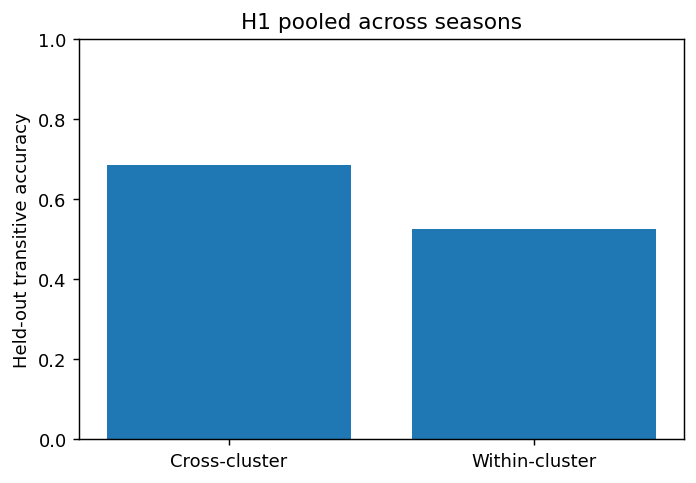

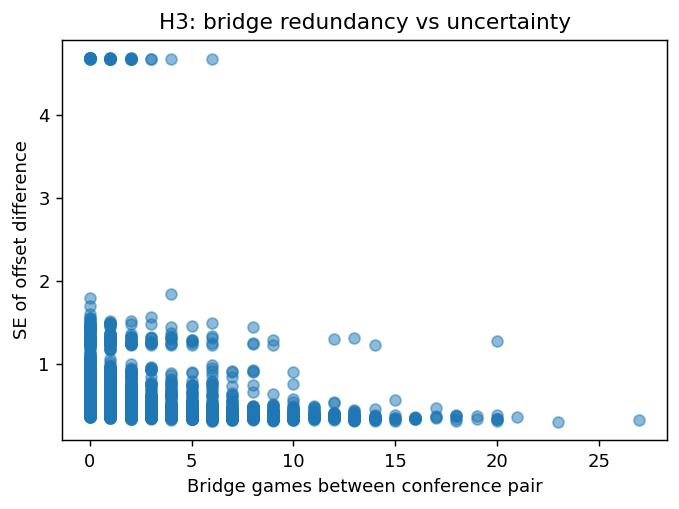

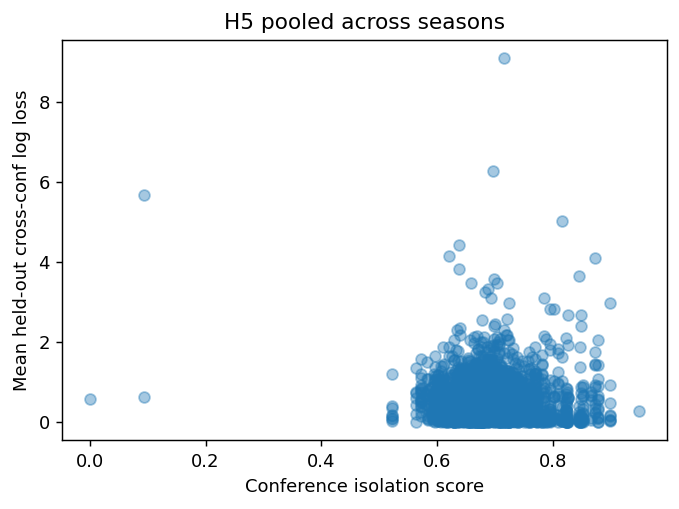

In [35]:

# Plot 1: H1 pooled accuracy
if 'h1_summary_overall' in globals() and not h1_summary_overall.empty:
    plt.figure(figsize=(6, 4))
    plt.bar(h1_summary_overall['ComparisonType'], h1_summary_overall['Accuracy'])
    plt.ylim(0, 1)
    plt.ylabel('Held-out transitive accuracy')
    plt.title('H1 pooled across seasons')
    plt.show()

# Plot 2: H3 bridge games vs uncertainty
if not h3_all.empty:
    plt.figure(figsize=(6, 4))
    plt.scatter(h3_all['BridgeGames'], h3_all['SE_OffsetDiff'], alpha=0.5)
    plt.xlabel('Bridge games between conference pair')
    plt.ylabel('SE of offset difference')
    plt.title('H3: bridge redundancy vs uncertainty')
    plt.show()

# Plot 3: H5 isolation vs team mis-evaluation
if not h5_all.empty:
    plt.figure(figsize=(6, 4))
    plt.scatter(h5_all['IsolationScore'], h5_all['MeanLogLoss_TeamOnly'], alpha=0.4)
    plt.xlabel('Conference isolation score')
    plt.ylabel('Mean held-out cross-conf log loss')
    plt.title('H5 pooled across seasons')
    plt.show()



## 18. How to read the expanded results

A good way to read this multi-year section is:

1. **H1 / H2** ask whether cluster-aware reasoning improves direct prediction.
2. **H3 / H4** ask whether bridge structure determines how comparable conference pairs are.
3. **H5 / H6** ask whether isolation and uncertainty predict where a conventional model struggles and where conference-aware adjustments help most.

If the predictive improvements remain weak but the uncertainty and bridge-structure results remain strong, that still supports a compelling paper story:

> NCAA schedule networks are highly modular, and bridge redundancy matters more for **comparability and identifiability** than for raw point-prediction gains.

That is a worthwhile and defensible network-science conclusion.



## 18. Tournament-performance extension

This section connects the **regular-season network metrics** to **NCAA tournament performance**.

The idea is simple: if bridge structure, centrality, uncertainty, and conference offsets are meaningful, some of those regular-season quantities should relate to what happens in March.

### Tournament hypotheses implemented here

- **H7:** Teams with higher cross-cluster connectivity perform better in the NCAA tournament.
- **H8:** Teams from conferences with higher bridge redundancy perform better in the NCAA tournament.
- **H9:** Teams with higher eigenvector centrality perform better in the tournament.
- **H10:** Teams with lower estimated rating uncertainty perform better in the tournament.
- **H11:** More insulated conferences underperform seed-based expectation in the tournament.
- **H12:** Network-based regular-season strength predicts tournament games at least as well as seed.
- **H13:** Teams with more diverse opponent-conference exposure perform better in the tournament.
- **H14:** Teams from conferences with stronger estimated conference offsets perform better in the tournament.
- **H15:** Teams with higher betweenness centrality outperform their seeds more often in the tournament.

The notebook uses the Kaggle tournament compact results and tournament seeds files already in the folder.


In [36]:

# Tournament file paths / load
TOURNEY_COMPACT_PATH = DATA_DIR / "MNCAATourneyCompactResults.csv"
TOURNEY_SEEDS_PATH = DATA_DIR / "MNCAATourneySeeds.csv"

if not TOURNEY_COMPACT_PATH.exists():
    raise FileNotFoundError(f"Missing required file: {TOURNEY_COMPACT_PATH}")
if not TOURNEY_SEEDS_PATH.exists():
    raise FileNotFoundError(f"Missing required file: {TOURNEY_SEEDS_PATH}")

tourney_compact = pd.read_csv(TOURNEY_COMPACT_PATH)
tourney_seeds = pd.read_csv(TOURNEY_SEEDS_PATH)

TOURNEY_SEASONS = sorted(set(HYPOTHESIS_SEASONS).intersection(set(tourney_compact["Season"]).intersection(set(tourney_seeds["Season"]))))
print(f"Tournament extension will use {len(TOURNEY_SEASONS)} seasons: {TOURNEY_SEASONS[0]} to {TOURNEY_SEASONS[-1]}")
print("tourney_compact:", tourney_compact.shape)
print("tourney_seeds:", tourney_seeds.shape)


Tournament extension will use 8 seasons: 2017 to 2025
tourney_compact: (2585, 8)
tourney_seeds: (2626, 3)


In [37]:

import re

def parse_seed_number(seed):
    if pd.isna(seed):
        return np.nan
    m = re.search(r"(\d{1,2})", str(seed))
    return int(m.group(1)) if m else np.nan


def build_tournament_outcomes(seasons, compact_df=tourney_compact, seeds_df=tourney_seeds):
    compact = compact_df.loc[compact_df["Season"].isin(seasons)].copy()
    seeds = seeds_df.loc[seeds_df["Season"].isin(seasons), ["Season", "TeamID", "Seed"]].copy()
    seeds["SeedNum"] = seeds["Seed"].map(parse_seed_number)

    wins = compact.groupby(["Season", "WTeamID"]).size().rename("TournamentWins").reset_index().rename(columns={"WTeamID": "TeamID"})
    losses = compact.groupby(["Season", "LTeamID"]).size().rename("TournamentLosses").reset_index().rename(columns={"LTeamID": "TeamID"})

    out = seeds.merge(wins, on=["Season", "TeamID"], how="left").merge(losses, on=["Season", "TeamID"], how="left")
    out["TournamentWins"] = out["TournamentWins"].fillna(0).astype(int)
    out["TournamentLosses"] = out["TournamentLosses"].fillna(0).astype(int)
    out["TournamentGames"] = out["TournamentWins"] + out["TournamentLosses"]
    out["RoundScore"] = out["TournamentWins"]
    out["MadeTournament"] = 1
    return out.sort_values(["Season", "SeedNum", "TeamID"]).reset_index(drop=True)


def build_seed_expectation_table(tourney_team_df):
    exp_tbl = (
        tourney_team_df.groupby("SeedNum")
        .agg(ExpectedTournamentWins=("TournamentWins", "mean"), Teams=("TeamID", "size"))
        .reset_index()
        .sort_values("SeedNum")
    )
    return exp_tbl


def build_team_network_tournament_metrics(season):
    G, DG, games, confs = build_graphs_for_season(season)
    conf_map = confs.set_index("TeamID")["ConfAbbrev"].to_dict()

    games = games.copy()
    games["WConf"] = games["WTeamID"].map(conf_map).fillna("unknown")
    games["LConf"] = games["LTeamID"].map(conf_map).fillna("unknown")
    games["SameConf"] = games["WConf"] == games["LConf"]

    team_ids = sorted(set(games["WTeamID"]).union(set(games["LTeamID"])))

    degree = dict(G.degree())
    weighted_degree = dict(G.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)
    try:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        eigenvector = nx.eigenvector_centrality(G, max_iter=2000, weight="weight")
    pagerank = nx.pagerank(DG, weight="weight")

    cross_deg = {tid: 0 for tid in team_ids}
    cross_wdeg = {tid: 0.0 for tid in team_ids}
    for u, v, data in G.edges(data=True):
        cu = G.nodes[u].get("Conference", "unknown")
        cv = G.nodes[v].get("Conference", "unknown")
        if cu != cv:
            w = float(data.get("weight", 1.0))
            cross_deg[u] += 1
            cross_deg[v] += 1
            cross_wdeg[u] += w
            cross_wdeg[v] += w

    opp_conf_rows = pd.concat([
        games[["WTeamID", "LConf"]].rename(columns={"WTeamID": "TeamID", "LConf": "OppConf"}),
        games[["LTeamID", "WConf"]].rename(columns={"LTeamID": "TeamID", "WConf": "OppConf"}),
    ], ignore_index=True)
    opp_entropy = {}
    for tid, grp in opp_conf_rows.groupby("TeamID"):
        counts = grp["OppConf"].value_counts()
        probs = counts / counts.sum()
        opp_entropy[int(tid)] = float(-(probs * np.log(probs)).sum()) if len(probs) else np.nan

    wins = games.groupby("WTeamID").size().rename("RegWins")
    losses = games.groupby("LTeamID").size().rename("RegLosses")
    standings = pd.DataFrame(index=team_ids)
    standings.index.name = "TeamID"
    standings = standings.join(wins, how="left").join(losses, how="left").fillna(0)
    standings["RegWins"] = standings["RegWins"].astype(int)
    standings["RegLosses"] = standings["RegLosses"].astype(int)
    standings["RegGames"] = standings["RegWins"] + standings["RegLosses"]
    standings["WinPct"] = np.where(standings["RegGames"] > 0, standings["RegWins"] / standings["RegGames"], np.nan)

    conf_games = games.loc[games["SameConf"]].copy()
    conf_wins = conf_games.groupby("WTeamID").size().rename("ConfWins")
    conf_losses = conf_games.groupby("LTeamID").size().rename("ConfLosses")
    standings = standings.join(conf_wins, how="left").join(conf_losses, how="left").fillna({"ConfWins":0, "ConfLosses":0})
    standings["ConfWins"] = standings["ConfWins"].astype(int)
    standings["ConfLosses"] = standings["ConfLosses"].astype(int)
    standings["ConfGames"] = standings["ConfWins"] + standings["ConfLosses"]
    standings["ConfWinPct"] = np.where(standings["ConfGames"] > 0, standings["ConfWins"] / standings["ConfGames"], np.nan)

    full_fit = fit_bradley_terry_team_cluster(games, team_ids, conf_map)
    _, cov = approximate_bt_hessian_team_cluster(games, full_fit, conf_map)
    p_team = len(full_fit["theta"])
    team_se = {tid: float(np.sqrt(max(cov[idx, idx], 0.0))) for tid, idx in full_fit["team_to_idx"].items()}
    conf_offset_map = {conf: float(full_fit["alpha"][i]) for i, conf in enumerate(full_fit["confs"])}
    team_theta_map = {tid: float(full_fit["theta"][full_fit["team_to_idx"][tid]]) for tid in team_ids}
    team_rating_map = {tid: float(team_theta_map[tid] + conf_offset_map.get(conf_map.get(tid, "unknown"), 0.0)) for tid in team_ids}

    conf_isolation = conference_isolation_table(games, confs)
    conf_isolation["Season"] = season
    conf_bridge_agg = conf_isolation.rename(columns={
        "ConfAbbrev": "Conference",
        "BetweenGames": "ConferenceBridgeGames",
        "DistinctOutsideConfs": "ConferenceDistinctOutsideConfs",
        "BridgeFraction": "ConferenceBridgeFraction",
        "IsolationScore": "ConferenceIsolationScore",
    })[["Season", "Conference", "ConferenceBridgeGames", "ConferenceDistinctOutsideConfs", "ConferenceBridgeFraction", "ConferenceIsolationScore"]]

    rows = []
    for tid in team_ids:
        conf = conf_map.get(tid, "unknown")
        rows.append({
            "Season": season,
            "TeamID": tid,
            "TeamName": team_name_map.get(tid, str(tid)),
            "Conference": conf,
            "Degree": degree.get(tid, np.nan),
            "WeightedDegree": weighted_degree.get(tid, np.nan),
            "BridgeDegree": cross_deg.get(tid, 0),
            "BridgeWeightedDegree": cross_wdeg.get(tid, 0.0),
            "Betweenness": betweenness.get(tid, np.nan),
            "EigenvectorCentrality": eigenvector.get(tid, np.nan),
            "PageRank": pagerank.get(tid, np.nan),
            "OpponentConferenceEntropy": opp_entropy.get(tid, np.nan),
            "TeamTheta": team_theta_map.get(tid, np.nan),
            "ConferenceOffset": conf_offset_map.get(conf, np.nan),
            "NetworkRating": team_rating_map.get(tid, np.nan),
            "TeamSE": team_se.get(tid, np.nan),
            "RegWins": standings.loc[tid, "RegWins"],
            "RegLosses": standings.loc[tid, "RegLosses"],
            "RegGames": standings.loc[tid, "RegGames"],
            "WinPct": standings.loc[tid, "WinPct"],
            "ConfWins": standings.loc[tid, "ConfWins"],
            "ConfLosses": standings.loc[tid, "ConfLosses"],
            "ConfGames": standings.loc[tid, "ConfGames"],
            "ConfWinPct": standings.loc[tid, "ConfWinPct"],
        })
    team_metrics = pd.DataFrame(rows).merge(conf_bridge_agg, on=["Season", "Conference"], how="left")
    return team_metrics, full_fit, conf_map, conf_bridge_agg


def build_tournament_game_prediction_rows(season, fit_obj, conf_map, compact_df=tourney_compact, seeds_df=tourney_seeds):
    games = compact_df.loc[compact_df["Season"] == season].copy()
    seeds = seeds_df.loc[seeds_df["Season"] == season, ["TeamID", "Seed"]].copy()
    seed_map = seeds.set_index("TeamID")["Seed"].to_dict()

    rows = []
    for r in games.itertuples():
        w = int(r.WTeamID)
        l = int(r.LTeamID)
        if w not in fit_obj["team_to_idx"] or l not in fit_obj["team_to_idx"]:
            continue
        seed_w = parse_seed_number(seed_map.get(w))
        seed_l = parse_seed_number(seed_map.get(l))
        rating_w = float(fit_obj["theta"][fit_obj["team_to_idx"][w]] + fit_obj["alpha"][fit_obj["conf_to_idx"][conf_map.get(w, "unknown")]])
        rating_l = float(fit_obj["theta"][fit_obj["team_to_idx"][l]] + fit_obj["alpha"][fit_obj["conf_to_idx"][conf_map.get(l, "unknown")]])
        rows.append({
            "Season": season,
            "WTeamID": w,
            "LTeamID": l,
            "WSeedNum": seed_w,
            "LSeedNum": seed_l,
            "WRating": rating_w,
            "LRating": rating_l,
            "SeedPredCorrect": 1 if (pd.notna(seed_w) and pd.notna(seed_l) and seed_w < seed_l) else (0 if (pd.notna(seed_w) and pd.notna(seed_l) and seed_w > seed_l) else np.nan),
            "NetworkPredCorrect": 1 if rating_w > rating_l else (0 if rating_w < rating_l else np.nan),
        })
    return pd.DataFrame(rows)


In [38]:

# Build pooled tournament-analysis tables across seasons
team_metric_rows = []
conf_metric_rows = []
tourney_pred_rows = []
season_metric_failures = []
season_model_cache = {}

for season in TOURNEY_SEASONS:
    try:
        print(f"Building tournament features for season {season}...")
        team_metrics_season, fit_obj_season, conf_map_season, conf_bridge_season = build_team_network_tournament_metrics(season)
        team_metric_rows.append(team_metrics_season)
        season_model_cache[season] = {
            "fit": fit_obj_season,
            "conf_map": conf_map_season,
        }

        tourney_pred_rows.append(build_tournament_game_prediction_rows(season, fit_obj_season, conf_map_season))
    except Exception as exc:
        season_metric_failures.append({"Season": season, "Error": repr(exc)})

team_metrics_all = pd.concat(team_metric_rows, ignore_index=True) if team_metric_rows else pd.DataFrame()
tourney_team_outcomes = build_tournament_outcomes(TOURNEY_SEASONS)
seed_expectation = build_seed_expectation_table(tourney_team_outcomes)

tourney_team_analysis = (
    tourney_team_outcomes
    .merge(team_metrics_all, on=["Season", "TeamID"], how="left")
    .merge(seed_expectation[["SeedNum", "ExpectedTournamentWins"]], on="SeedNum", how="left")
)
tourney_team_analysis["WinsAboveSeedExpectation"] = tourney_team_analysis["TournamentWins"] - tourney_team_analysis["ExpectedTournamentWins"]

tourney_pred_all = pd.concat(tourney_pred_rows, ignore_index=True) if tourney_pred_rows else pd.DataFrame()
season_metric_failures = pd.DataFrame(season_metric_failures)

conference_tourney_analysis = (
    tourney_team_analysis
    .groupby(["Season", "Conference"], as_index=False)
    .agg(
        Bids=("TeamID", "size"),
        ConferenceTournamentWins=("TournamentWins", "sum"),
        AvgTournamentWins=("TournamentWins", "mean"),
        AvgWinsAboveSeedExpectation=("WinsAboveSeedExpectation", "mean"),
        MeanSeedNum=("SeedNum", "mean"),
        ConferenceBridgeGames=("ConferenceBridgeGames", "mean"),
        ConferenceDistinctOutsideConfs=("ConferenceDistinctOutsideConfs", "mean"),
        ConferenceBridgeFraction=("ConferenceBridgeFraction", "mean"),
        ConferenceIsolationScore=("ConferenceIsolationScore", "mean"),
        ConferenceOffset=("ConferenceOffset", "mean"),
    )
)
conference_tourney_analysis["WinsPerBid"] = np.where(
    conference_tourney_analysis["Bids"] > 0,
    conference_tourney_analysis["ConferenceTournamentWins"] / conference_tourney_analysis["Bids"],
    np.nan,
)

print("Tournament team analysis rows:", len(tourney_team_analysis))
print("Tournament game prediction rows:", len(tourney_pred_all))
print("Conference tournament rows:", len(conference_tourney_analysis))
if not season_metric_failures.empty:
    print("Season metric failures:")
    display(season_metric_failures)

save_table(seed_expectation, "tourney_seed_expectation")
save_table(tourney_team_analysis, "tourney_team_analysis")
save_table(conference_tourney_analysis, "tourney_conference_analysis")


Building tournament features for season 2017...
Building tournament features for season 2018...
Building tournament features for season 2019...
Building tournament features for season 2021...
Building tournament features for season 2022...
Building tournament features for season 2023...
Building tournament features for season 2024...
Building tournament features for season 2025...
Tournament team analysis rows: 544
Tournament game prediction rows: 535
Conference tournament rows: 254
Saved: outputs/tourney_seed_expectation.csv
Saved: outputs/tourney_team_analysis.csv
Saved: outputs/tourney_conference_analysis.csv



### 18A. Tournament data diagnostics

These tables show the team-level and conference-level tournament analysis frames that will support H7–H15.


In [39]:

display(seed_expectation.head(16))
display(tourney_team_analysis.head(20))
display(conference_tourney_analysis.head(20))


,SeedNum,ExpectedTournamentWins,Teams
0,1,3.281250,32
1,2,2.062500,32
2,3,2.000000,32
3,4,1.625000,32
4,5,1.281250,32
5,6,0.750000,32
6,7,0.843750,32
7,8,0.625000,32
8,9,0.812500,32
9,10,0.500000,34


,Season,TeamID,Seed,SeedNum,TournamentWins,TournamentLosses,TournamentGames,RoundScore,MadeTournament,TeamName,Conference,Degree,WeightedDegree,BridgeDegree,BridgeWeightedDegree,Betweenness,EigenvectorCentrality,PageRank,OpponentConferenceEntropy,TeamTheta,ConferenceOffset,NetworkRating,TeamSE,RegWins,RegLosses,RegGames,WinPct,ConfWins,ConfLosses,ConfGames,ConfWinPct,ConferenceBridgeGames,ConferenceDistinctOutsideConfs,ConferenceBridgeFraction,ConferenceIsolationScore,ExpectedTournamentWins,WinsAboveSeedExpectation
0,2017,1211,X01,1,5,1,6,5,1,Gonzaga,wcc,21,33,12,12.0,0.005572,0.056434,0.012668,1.475066,4.871677,1.035926,5.907603,1.039091,32,1,33,0.969697,20,1,21,0.952381,115,25,0.367412,0.632588,3.28125,1.71875
1,2017,1242,Y01,1,3,1,4,3,1,Kansas,big_twelve,22,32,13,13.0,0.004337,0.061253,0.012783,1.630832,2.076043,2.771232,4.847275,0.530324,28,4,32,0.875000,16,3,19,0.842105,125,28,0.386997,0.613003,3.28125,-0.28125
2,2017,1314,Z01,1,6,0,6,6,1,North Carolina,acc,27,33,13,13.0,0.005295,0.064330,0.011660,1.554885,1.410349,3.011271,4.421620,0.449754,26,7,33,0.787879,15,5,20,0.750000,189,30,0.388090,0.611910,3.28125,2.71875
3,2017,1437,W01,1,1,1,2,1,1,Villanova,big_east,22,34,13,13.0,0.003383,0.066557,0.014318,1.426664,2.559133,2.721395,5.280529,0.580008,31,3,34,0.911765,18,3,21,0.857143,126,30,0.388889,0.611111,3.28125,-2.28125
4,2017,1112,X02,2,2,1,3,2,1,Arizona,pac_twelve,24,34,13,13.0,0.004721,0.060620,0.011665,1.523600,2.985073,2.057365,5.042438,0.625521,30,4,34,0.882353,19,2,21,0.904762,144,25,0.376963,0.623037,2.06250,-0.06250
5,2017,1181,W02,2,1,1,2,1,1,Duke,acc,27,35,13,13.0,0.005592,0.067826,0.013449,1.533190,1.417551,3.011271,4.428821,0.428467,27,8,35,0.771429,15,7,22,0.681818,189,30,0.388090,0.611910,2.06250,-1.06250
6,2017,1246,Z02,2,3,1,4,3,1,Kentucky,sec,26,34,13,13.0,0.005401,0.065087,0.008444,1.523600,2.348593,2.203476,4.552069,0.519104,29,5,34,0.852941,19,2,21,0.904762,174,30,0.384956,0.615044,2.06250,0.93750
7,2017,1257,Y02,2,1,1,2,1,1,Louisville,acc,27,32,13,13.0,0.005308,0.061930,0.010818,1.571159,1.216605,3.011271,4.227876,0.438906,24,8,32,0.750000,12,7,19,0.631579,189,30,0.388090,0.611910,2.06250,-1.06250
8,2017,1124,W03,3,2,1,3,2,1,Baylor,big_twelve,21,31,12,12.0,0.003222,0.058816,0.010563,1.523014,1.387203,2.771232,4.158435,0.446285,24,7,31,0.774194,12,7,19,0.631579,125,28,0.386997,0.613003,2.00000,0.00000
9,2017,1199,X03,3,1,1,2,1,1,Florida St,acc,27,33,13,13.0,0.005682,0.063698,0.011141,1.554885,1.142680,3.011271,4.153950,0.436702,25,8,33,0.757576,13,7,20,0.650000,189,30,0.388090,0.611910,2.00000,-1.00000


,Season,Conference,Bids,ConferenceTournamentWins,AvgTournamentWins,AvgWinsAboveSeedExpectation,MeanSeedNum,ConferenceBridgeGames,ConferenceDistinctOutsideConfs,ConferenceBridgeFraction,ConferenceIsolationScore,ConferenceOffset,WinsPerBid
0,2017,a_sun,1,0,0.000000,-0.062500,14.000000,108.0,28.0,0.461538,0.538462,0.000000,0.000000
1,2017,a_ten,3,1,0.333333,-0.440509,9.333333,170.0,29.0,0.379464,0.620536,1.088024,0.333333
2,2017,aac,2,1,0.500000,-0.250000,6.000000,135.0,30.0,0.382436,0.617564,1.185894,0.500000
3,2017,acc,9,11,1.222222,-0.376003,5.111111,189.0,30.0,0.388090,0.611910,3.011271,1.222222
4,2017,aec,1,0,0.000000,-0.218750,13.000000,118.0,25.0,0.427536,0.572464,-0.540287,0.000000
5,2017,big_east,7,6,0.857143,-0.417758,7.428571,126.0,30.0,0.388889,0.611111,2.721395,0.857143
6,2017,big_sky,1,0,0.000000,-0.218750,15.000000,120.0,26.0,0.337079,0.662921,-1.006175,0.000000
7,2017,big_south,1,0,0.000000,-0.218750,13.000000,94.0,22.0,0.321918,0.678082,-0.650060,0.000000
8,2017,big_ten,7,8,1.142857,0.205357,6.714286,177.0,29.0,0.389011,0.610989,2.758671,1.142857
9,2017,big_twelve,6,9,1.500000,-0.110880,5.666667,125.0,28.0,0.386997,0.613003,2.771232,1.500000



### 18B. H7, H9, H10, H13, H14, and H15 — team-level tournament hypotheses

These tests ask whether regular-season team metrics are associated with tournament wins and seed-adjusted overperformance.


In [40]:

team_hypothesis_rows = []
team_level_tests = [
    ("H7", "BridgeWeightedDegree", "TournamentWins", "Higher cross-cluster connectivity"),
    ("H7", "BridgeWeightedDegree", "WinsAboveSeedExpectation", "Higher cross-cluster connectivity"),
    ("H9", "EigenvectorCentrality", "TournamentWins", "Higher eigenvector centrality"),
    ("H9", "EigenvectorCentrality", "WinsAboveSeedExpectation", "Higher eigenvector centrality"),
    ("H10", "TeamSE", "TournamentWins", "Lower uncertainty expected to help"),
    ("H10", "TeamSE", "WinsAboveSeedExpectation", "Lower uncertainty expected to help"),
    ("H13", "OpponentConferenceEntropy", "TournamentWins", "More diverse conference exposure"),
    ("H13", "OpponentConferenceEntropy", "WinsAboveSeedExpectation", "More diverse conference exposure"),
    ("H14", "ConferenceOffset", "TournamentWins", "Stronger conference offset"),
    ("H14", "ConferenceOffset", "WinsAboveSeedExpectation", "Stronger conference offset"),
    ("H15", "Betweenness", "TournamentWins", "Higher betweenness centrality"),
    ("H15", "Betweenness", "WinsAboveSeedExpectation", "Higher betweenness centrality"),
]

team_eval_df = tourney_team_analysis.dropna(subset=["TournamentWins", "SeedNum"]).copy()

for hyp, metric, outcome, note in team_level_tests:
    rho, pval, nobs = safe_spearman(team_eval_df[metric], team_eval_df[outcome])
    team_hypothesis_rows.append({
        "Hypothesis": hyp,
        "Metric": metric,
        "Outcome": outcome,
        "SpearmanR": rho,
        "PValue": pval,
        "N": nobs,
        "Note": note,
    })

team_hypothesis_summary = pd.DataFrame(team_hypothesis_rows)
display(team_hypothesis_summary)
save_table(team_hypothesis_summary, "tourney_team_hypothesis_summary")


,Hypothesis,Metric,Outcome,SpearmanR,PValue,N,Note
0,H7,BridgeWeightedDegree,TournamentWins,0.087059,4.238422e-02,544,Higher cross-cluster connectivity
1,H7,BridgeWeightedDegree,WinsAboveSeedExpectation,-0.061349,1.530167e-01,544,Higher cross-cluster connectivity
2,H9,EigenvectorCentrality,TournamentWins,0.417939,2.068298e-24,544,Higher eigenvector centrality
3,H9,EigenvectorCentrality,WinsAboveSeedExpectation,0.014544,7.350197e-01,544,Higher eigenvector centrality
4,H10,TeamSE,TournamentWins,0.098275,2.188060e-02,544,Lower uncertainty expected to help
5,H10,TeamSE,WinsAboveSeedExpectation,-0.006062,8.878227e-01,544,Lower uncertainty expected to help
6,H13,OpponentConferenceEntropy,TournamentWins,0.072198,9.251738e-02,544,More diverse conference exposure
7,H13,OpponentConferenceEntropy,WinsAboveSeedExpectation,-0.063911,1.365585e-01,544,More diverse conference exposure
8,H14,ConferenceOffset,TournamentWins,0.377179,7.804012e-20,544,Stronger conference offset
9,H14,ConferenceOffset,WinsAboveSeedExpectation,-0.061743,1.503955e-01,544,Stronger conference offset


Saved: outputs/tourney_team_hypothesis_summary.csv



### 18C. H8 and H11 — conference-level tournament hypotheses

These tests ask whether conference bridge structure or conference insulation relates to average tournament performance.


In [41]:

conference_hypothesis_rows = []
conference_tests = [
    ("H8", "ConferenceBridgeGames", "WinsPerBid", "More bridge games should help conference tournament performance"),
    ("H8", "ConferenceBridgeFraction", "WinsPerBid", "More bridge share should help conference tournament performance"),
    ("H8", "ConferenceBridgeGames", "AvgWinsAboveSeedExpectation", "More bridge games should help seed-adjusted conference performance"),
    ("H8", "ConferenceBridgeFraction", "AvgWinsAboveSeedExpectation", "More bridge share should help seed-adjusted conference performance"),
    ("H11", "ConferenceIsolationScore", "WinsPerBid", "More insulated conferences may underperform"),
    ("H11", "ConferenceIsolationScore", "AvgWinsAboveSeedExpectation", "More insulated conferences may underperform relative to seed"),
]

conf_eval_df = conference_tourney_analysis.dropna(subset=["WinsPerBid", "AvgWinsAboveSeedExpectation"]).copy()
for hyp, metric, outcome, note in conference_tests:
    rho, pval, nobs = safe_spearman(conf_eval_df[metric], conf_eval_df[outcome])
    conference_hypothesis_rows.append({
        "Hypothesis": hyp,
        "Metric": metric,
        "Outcome": outcome,
        "SpearmanR": rho,
        "PValue": pval,
        "N": nobs,
        "Note": note,
    })

conference_hypothesis_summary = pd.DataFrame(conference_hypothesis_rows)
display(conference_hypothesis_summary)
save_table(conference_hypothesis_summary, "tourney_conference_hypothesis_summary")


,Hypothesis,Metric,Outcome,SpearmanR,PValue,N,Note
0,H8,ConferenceBridgeGames,WinsPerBid,0.248920,0.000060,254,More bridge games should help conference tourn...
1,H8,ConferenceBridgeFraction,WinsPerBid,-0.000240,0.996964,254,More bridge share should help conference tourn...
2,H8,ConferenceBridgeGames,AvgWinsAboveSeedExpectation,-0.023525,0.709050,254,More bridge games should help seed-adjusted co...
3,H8,ConferenceBridgeFraction,AvgWinsAboveSeedExpectation,-0.101122,0.107880,254,More bridge share should help seed-adjusted co...
4,H11,ConferenceIsolationScore,WinsPerBid,-0.000420,0.994691,254,More insulated conferences may underperform
5,H11,ConferenceIsolationScore,AvgWinsAboveSeedExpectation,0.100510,0.110041,254,More insulated conferences may underperform re...


Saved: outputs/tourney_conference_hypothesis_summary.csv



### 18D. H12 — seed vs. network-based tournament game prediction

This compares two very simple regular-season tournament baselines:

- **Seed baseline:** pick the better numerical seed.
- **Network baseline:** pick the team with the higher regular-season team+conference rating.

The goal is not to build a state-of-the-art bracket model; it is to test whether your network metric is competitive with an obvious March benchmark.


In [42]:

if tourney_pred_all.empty:
    print("H12 could not be evaluated because tournament prediction rows are empty.")
    h12_summary_overall = pd.DataFrame()
else:
    h12_summary_overall = pd.DataFrame([
        {
            "Model": "Seed baseline",
            "Accuracy": float(np.nanmean(tourney_pred_all["SeedPredCorrect"])),
            "N": int(tourney_pred_all["SeedPredCorrect"].notna().sum()),
        },
        {
            "Model": "Network rating baseline",
            "Accuracy": float(np.nanmean(tourney_pred_all["NetworkPredCorrect"])),
            "N": int(tourney_pred_all["NetworkPredCorrect"].notna().sum()),
        },
    ])

    h12_by_season = []
    for season, grp in tourney_pred_all.groupby("Season"):
        h12_by_season.append({
            "Season": season,
            "SeedAccuracy": float(np.nanmean(grp["SeedPredCorrect"])),
            "NetworkAccuracy": float(np.nanmean(grp["NetworkPredCorrect"])),
            "Games": int(len(grp)),
        })
    h12_by_season = pd.DataFrame(h12_by_season)

    display(h12_summary_overall)
    display(h12_by_season)
    save_table(tourney_pred_all, "tourney_game_prediction_rows")
    save_table(h12_summary_overall, "tourney_h12_summary_overall")
    save_table(h12_by_season, "tourney_h12_summary_by_season")


,Model,Accuracy,N
0,Seed baseline,0.711694,496
1,Network rating baseline,0.669159,535


,Season,SeedAccuracy,NetworkAccuracy,Games
0,2017,0.774194,0.671642,67
1,2018,0.677419,0.641791,67
2,2019,0.682540,0.716418,67
3,2021,0.688525,0.636364,66
4,2022,0.666667,0.626866,67
5,2023,0.698413,0.656716,67
6,2024,0.693548,0.641791,67
7,2025,0.816667,0.761194,67


Saved: outputs/tourney_game_prediction_rows.csv
Saved: outputs/tourney_h12_summary_overall.csv
Saved: outputs/tourney_h12_summary_by_season.csv



### 18E. Compact plots for the tournament extension


Saved: outputs/tourney_bridge_degree_vs_wins.png


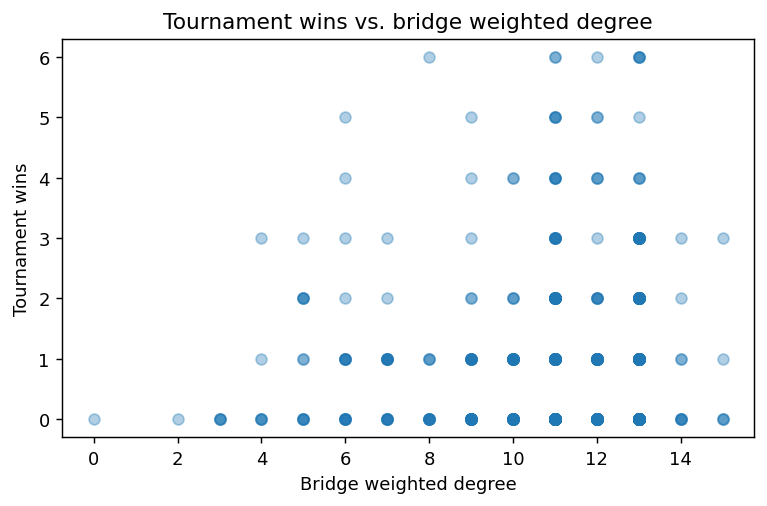

Saved: outputs/tourney_teamse_vs_wins.png


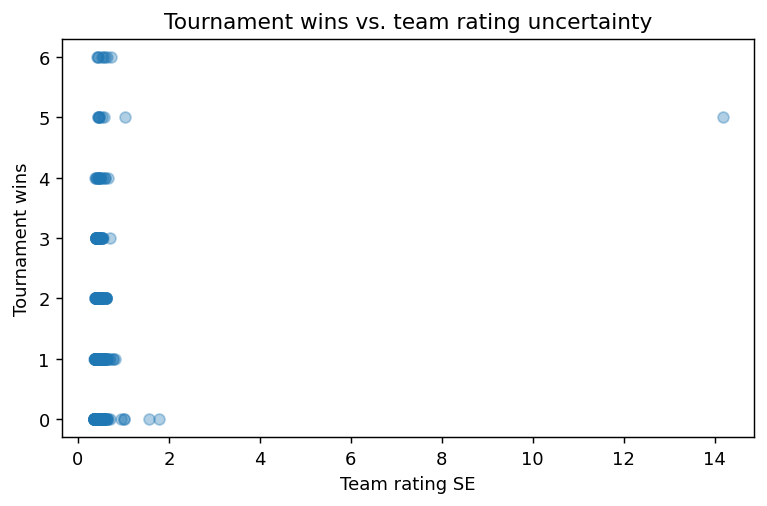

Saved: outputs/tourney_seed_vs_network_accuracy.png


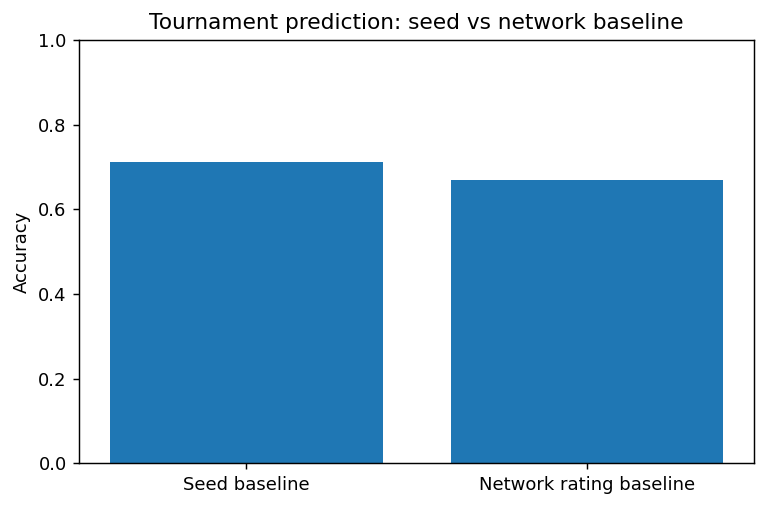

In [43]:

# Plot A: H7 / bridge connectivity vs tournament wins
if not tourney_team_analysis.empty:
    plt.figure(figsize=(6, 4))
    x = tourney_team_analysis["BridgeWeightedDegree"]
    y = tourney_team_analysis["TournamentWins"]
    plt.scatter(x, y, alpha=0.35)
    plt.xlabel("Bridge weighted degree")
    plt.ylabel("Tournament wins")
    finish_figure("Tournament wins vs. bridge weighted degree", "tourney_bridge_degree_vs_wins.png")

# Plot B: H10 / uncertainty vs tournament wins
if not tourney_team_analysis.empty:
    plt.figure(figsize=(6, 4))
    x = tourney_team_analysis["TeamSE"]
    y = tourney_team_analysis["TournamentWins"]
    plt.scatter(x, y, alpha=0.35)
    plt.xlabel("Team rating SE")
    plt.ylabel("Tournament wins")
    finish_figure("Tournament wins vs. team rating uncertainty", "tourney_teamse_vs_wins.png")

# Plot C: H12 seed vs network tournament prediction accuracy
if 'h12_summary_overall' in globals() and not h12_summary_overall.empty:
    plt.figure(figsize=(6, 4))
    plt.bar(h12_summary_overall["Model"], h12_summary_overall["Accuracy"])
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    finish_figure("Tournament prediction: seed vs network baseline", "tourney_seed_vs_network_accuracy.png")
